In [1]:
# ============================================================
#  CELL 1: Install Dependencies & Suppress Warnings
# ============================================================
!pip install -q tensorflow scikit-learn pandas numpy matplotlib seaborn

import warnings
warnings.filterwarnings('ignore')
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

print("✅ Cell 1 Complete")

✅ Cell 1 Complete


In [2]:
# ============================================================
#  CELL 2: Import Libraries + Single GPU Setup
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time, gc
from math import pi

from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, f1_score, accuracy_score,
    precision_score, recall_score, average_precision_score
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, regularizers, backend as K
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

np.random.seed(42)
tf.random.set_seed(42)

# ============================================================
#  SINGLE GPU SETUP
# ============================================================
print(f"TensorFlow Version : {tf.__version__}")

gpus = tf.config.list_physical_devices('GPU')
print(f"GPUs Available     : {len(gpus)}")

if len(gpus) > 0:
    # Use ONLY the first GPU
    try:
        tf.config.set_visible_devices(gpus[0], 'GPU')
        tf.config.experimental.set_memory_growth(gpus[0], True)
        print(f"✅ Using GPU 0: {gpus[0].name}")
        print(f"   Memory growth enabled")
    except RuntimeError as e:
        print(f"⚠ GPU setup error: {e}")
else:
    print("⚠ No GPU found — using CPU")

# Verify only 1 GPU is visible
visible = tf.config.get_visible_devices('GPU')
print(f"Visible GPUs       : {len(visible)}")

print("✅ Cell 2 Complete")

E0000 00:00:1771920078.888444      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771920078.948888      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771920079.403495      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771920079.403560      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771920079.403563      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771920079.403566      55 computation_placer.cc:177] computation placer already registered. Please check linka

TensorFlow Version : 2.19.0
GPUs Available     : 2
✅ Using GPU 0: /physical_device:GPU:0
   Memory growth enabled
Visible GPUs       : 1
✅ Cell 2 Complete


In [3]:
# ============================================================
#  CELL 3: Load Dataset
# ============================================================
POSSIBLE_PATHS = [
    '/kaggle/input/ton-iot-network/Train_Test_Network.csv',
    '/kaggle/input/toniot/NF-ToN-IoT.csv',
    '/kaggle/input/ton-iot-dataset/Train_Test_Network.csv',
    '/content/Train_Test_Network.csv',
    '/kaggle/input/network/train_test_network.csv',
    'NF-ToN-IoT.csv',
]

df = None
for p in POSSIBLE_PATHS:
    if os.path.exists(p):
        df = pd.read_csv(p, low_memory=False)
        print(f"✅ Loaded from: {p}")
        break

if df is None:
    raise FileNotFoundError(
        "Dataset not found! Upload TON_IoT CSV and update path.\n"
        "Download: https://research.unsw.edu.au/projects/toniot-datasets"
    )

print(f"Shape   : {df.shape}")
print(f"Columns : {list(df.columns)}")
print("✅ Cell 3 Complete")

✅ Loaded from: /kaggle/input/network/train_test_network.csv
Shape   : (211043, 44)
Columns : ['src_ip', 'src_port', 'dst_ip', 'dst_port', 'proto', 'service', 'duration', 'src_bytes', 'dst_bytes', 'conn_state', 'missed_bytes', 'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes', 'dns_query', 'dns_qclass', 'dns_qtype', 'dns_rcode', 'dns_AA', 'dns_RD', 'dns_RA', 'dns_rejected', 'ssl_version', 'ssl_cipher', 'ssl_resumed', 'ssl_established', 'ssl_subject', 'ssl_issuer', 'http_trans_depth', 'http_method', 'http_uri', 'http_version', 'http_request_body_len', 'http_response_body_len', 'http_status_code', 'http_user_agent', 'http_orig_mime_types', 'http_resp_mime_types', 'weird_name', 'weird_addl', 'weird_notice', 'label', 'type']
✅ Cell 3 Complete


         TON_IoT NETWORK DATASET — DEEP ANALYSIS

Shape: (211043, 44)
Columns (44): ['src_ip', 'src_port', 'dst_ip', 'dst_port', 'proto', 'service', 'duration', 'src_bytes', 'dst_bytes', 'conn_state', 'missed_bytes', 'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes', 'dns_query', 'dns_qclass', 'dns_qtype', 'dns_rcode', 'dns_AA', 'dns_RD', 'dns_RA', 'dns_rejected', 'ssl_version', 'ssl_cipher', 'ssl_resumed', 'ssl_established', 'ssl_subject', 'ssl_issuer', 'http_trans_depth', 'http_method', 'http_uri', 'http_version', 'http_request_body_len', 'http_response_body_len', 'http_status_code', 'http_user_agent', 'http_orig_mime_types', 'http_resp_mime_types', 'weird_name', 'weird_addl', 'weird_notice', 'label', 'type']

  DATA TYPES

  object (27 columns):
    src_ip                         | unique=51       | null=0.0%
    dst_ip                         | unique=753      | null=0.0%
    proto                          | unique=3        | null=0.0%
    service                        | uniq

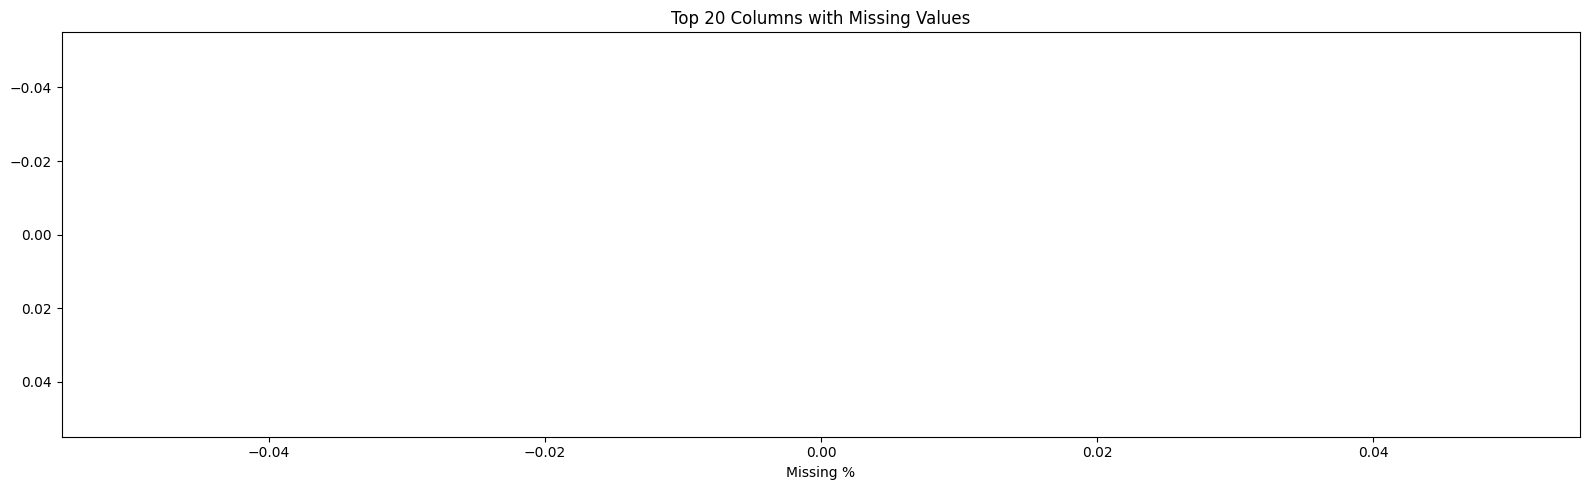

✅ Cell 4 Complete


In [4]:
# ============================================================
#  CELL 4: Deep EDA — TON_IoT Network Dataset Specific
# ============================================================

print("=" * 70)
print("         TON_IoT NETWORK DATASET — DEEP ANALYSIS")
print("=" * 70)

# ── 1. Basic Info ──
print(f"\nShape: {df.shape}")
print(f"Columns ({len(df.columns)}): {list(df.columns)}")

# ── 2. Data Types ──
print("\n" + "=" * 70)
print("  DATA TYPES")
print("=" * 70)
for dtype, count in df.dtypes.value_counts().items():
    cols = df.select_dtypes(include=[dtype]).columns.tolist()
    print(f"\n  {dtype} ({count} columns):")
    for c in cols:
        nunique = df[c].nunique()
        null_pct = df[c].isnull().mean() * 100
        print(f"    {c:<30} | unique={nunique:<8} | null={null_pct:.1f}%")

# ── 3. Missing Values Deep Dive ──
print("\n" + "=" * 70)
print("  MISSING VALUES ANALYSIS")
print("=" * 70)
miss = df.isnull().sum()
miss_pct = (df.isnull().mean() * 100).round(2)
miss_df = pd.DataFrame({
    'Column': miss.index,
    'Missing': miss.values,
    'Pct': miss_pct.values
}).sort_values('Pct', ascending=False)
miss_df = miss_df[miss_df['Missing'] > 0]
print(f"\n  {len(miss_df)} columns have missing values:")
for _, r in miss_df.iterrows():
    print(f"    {r['Column']:<30} | {r['Missing']:>8,} ({r['Pct']:.1f}%)")

# ── 4. Identify TON_IoT Specific Column Groups ──
print("\n" + "=" * 70)
print("  TON_IoT COLUMN GROUPS")
print("=" * 70)

all_cols = df.columns.tolist()

# Identify groups
identifier_cols = [c for c in all_cols if any(k in c.lower()
                   for k in ['src_ip', 'dst_ip', 'ts'])]
dns_cols = [c for c in all_cols if 'dns_' in c.lower()]
ssl_cols = [c for c in all_cols if 'ssl_' in c.lower()]
http_cols = [c for c in all_cols if 'http_' in c.lower()]
weird_cols = [c for c in all_cols if 'weird_' in c.lower()]
label_cols_found = [c for c in all_cols if c.lower() in ('label', 'type')]
core_cols = [c for c in all_cols if c not in
             identifier_cols + dns_cols + ssl_cols + http_cols +
             weird_cols + label_cols_found]

print(f"  Identifiers    : {identifier_cols}")
print(f"  Core Network   : {core_cols}")
print(f"  DNS fields     : {dns_cols}")
print(f"  SSL fields     : {ssl_cols}")
print(f"  HTTP fields    : {http_cols}")
print(f"  Weird fields   : {weird_cols}")
print(f"  Labels         : {label_cols_found}")

# ── 5. Skewness Analysis ──
print("\n" + "=" * 70)
print("  SKEWNESS ANALYSIS (Numeric Features)")
print("=" * 70)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c.lower() not in ('label',)]
skew_vals = df[num_cols].skew().sort_values(ascending=False)
print(f"\n  Highly skewed features (|skew| > 5):")
for c, s in skew_vals.items():
    if abs(s) > 5:
        print(f"    {c:<30} | skew={s:>12.2f}")

# ── 6. Constant/Quasi-constant Detection ──
print("\n" + "=" * 70)
print("  CONSTANT / QUASI-CONSTANT FEATURES")
print("=" * 70)
for c in all_cols:
    nunique = df[c].nunique()
    if nunique <= 1:
        print(f"    {c:<30} | CONSTANT (1 unique value)")
    elif nunique <= 2 and c.lower() not in ('label',):
        dominant_pct = df[c].value_counts(normalize=True).iloc[0] * 100
        if dominant_pct > 99:
            print(f"    {c:<30} | QUASI-CONSTANT ({dominant_pct:.1f}% same)")

# ── 7. Boolean-like columns (T/F) ──
print("\n" + "=" * 70)
print("  BOOLEAN-LIKE COLUMNS (T/F/True/False)")
print("=" * 70)
for c in df.select_dtypes(include=['object']).columns:
    unique_vals = set(df[c].dropna().unique())
    if unique_vals.issubset({'T', 'F', 'True', 'False', 'true', 'false',
                             't', 'f', 'TRUE', 'FALSE', '-'}):
        print(f"    {c:<30} | values: {unique_vals}")

plt.figure(figsize=(16, 5))
miss_top = miss_df.head(20)
plt.barh(miss_top['Column'], miss_top['Pct'], color='#e74c3c')
plt.xlabel('Missing %')
plt.title('Top 20 Columns with Missing Values')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("✅ Cell 4 Complete")

Label column : label
Type  column : type


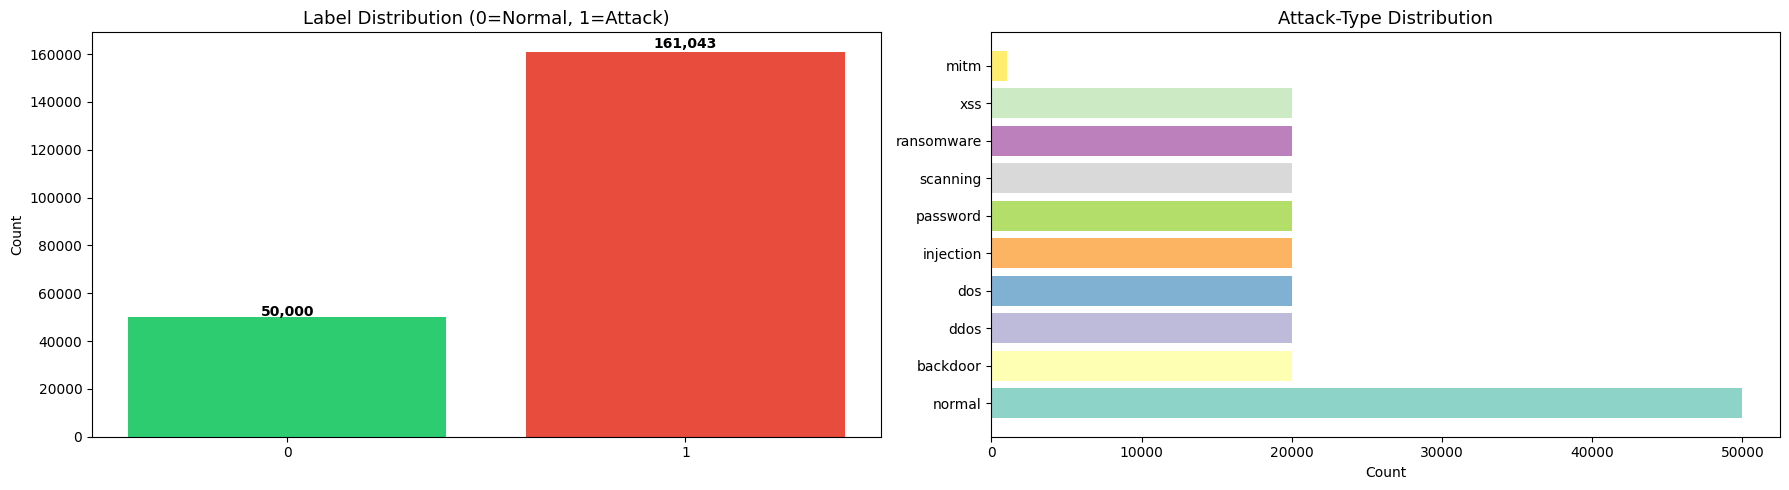


Normal : 50,000
Attack : 161,043
✅ Cell 5 Complete


In [5]:
# ============================================================
#  CELL 5: Label & Attack Type Distribution
# ============================================================

# Auto-detect label column
label_col = [c for c in df.columns if c.lower() in ('label',)][0]
type_candidates = [c for c in df.columns
                   if c.lower() in ('type', 'attack_type', 'attack_cat', 'attack')]
type_col = type_candidates[0] if type_candidates else None

print(f"Label column : {label_col}")
print(f"Type  column : {type_col}")

# Handle string labels
if df[label_col].dtype == object:
    df[label_col] = df[label_col].map(
        lambda x: 0 if str(x).lower() in ('normal', 'benign', '0') else 1
    )

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Label distribution
lc = df[label_col].value_counts().sort_index()
bars = axes[0].bar(lc.index.astype(str), lc.values,
                   color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Label Distribution (0=Normal, 1=Attack)', fontsize=13)
axes[0].set_ylabel('Count')
for b in bars:
    axes[0].text(b.get_x() + b.get_width() / 2, b.get_height() * 1.01,
                 f'{int(b.get_height()):,}', ha='center', fontweight='bold')

# Attack type distribution
if type_col:
    tc = df[type_col].value_counts()
    axes[1].barh(tc.index.astype(str), tc.values,
                 color=plt.cm.Set3(np.linspace(0, 1, len(tc))))
    axes[1].set_title('Attack-Type Distribution', fontsize=13)
    axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()

print(f"\nNormal : {(df[label_col] == 0).sum():,}")
print(f"Attack : {(df[label_col] == 1).sum():,}")
print("✅ Cell 5 Complete")

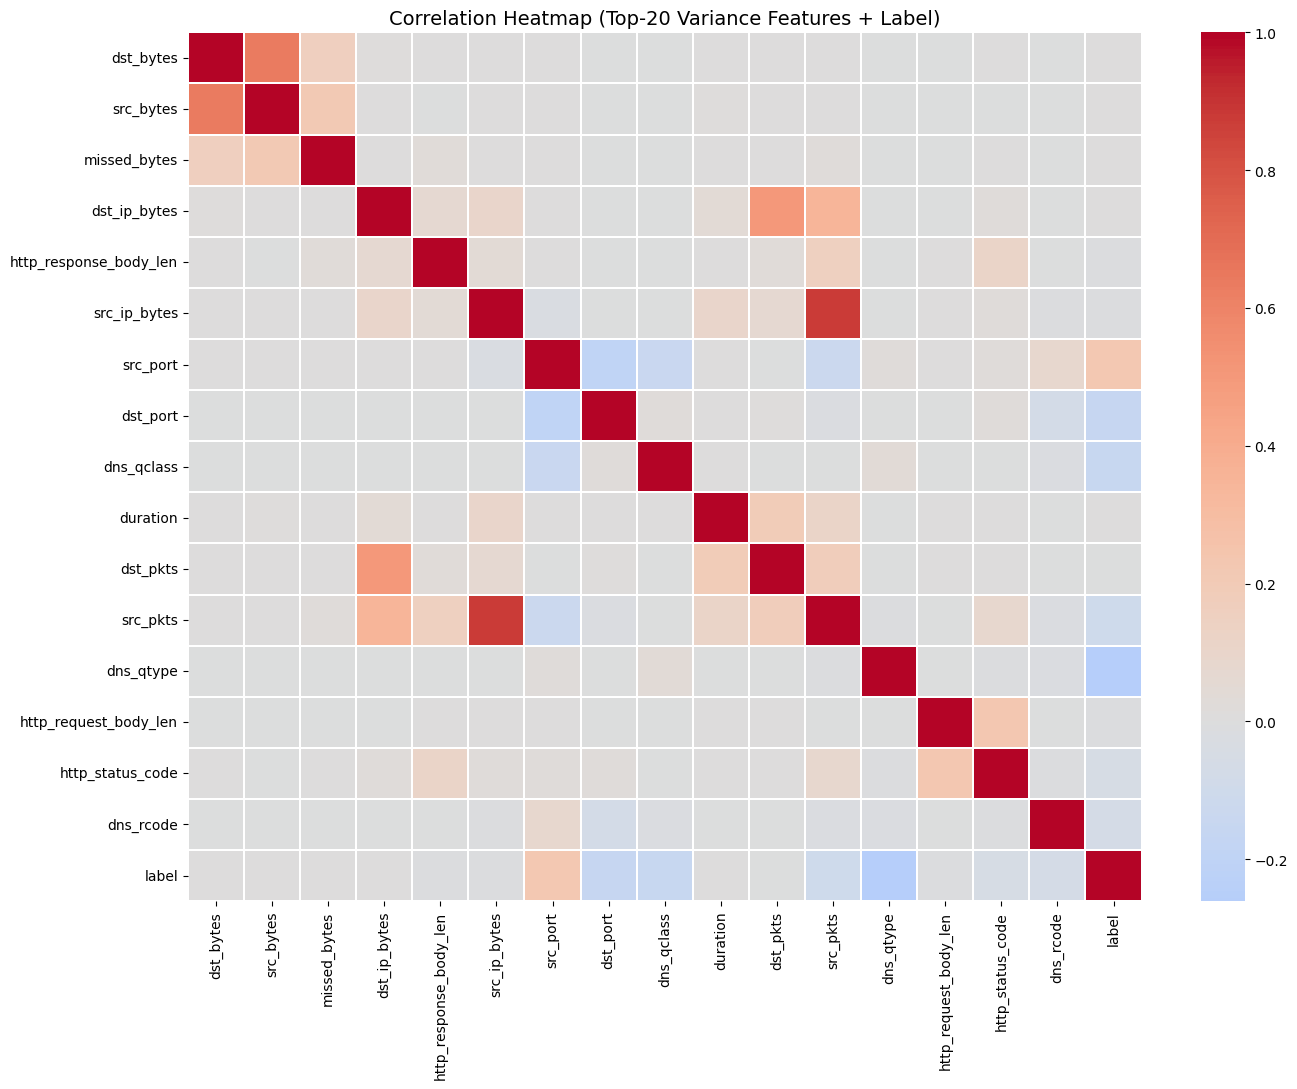

✅ Cell 6 Complete


In [6]:
# ============================================================
#  CELL 6: Correlation Heatmap (Top-20 Variance Features)
# ============================================================
num_feats = df.select_dtypes(include=[np.number]).columns.tolist()
num_feats = [c for c in num_feats if c != label_col]

top = df[num_feats].var().nlargest(20).index.tolist()

plt.figure(figsize=(14, 11))
sns.heatmap(df[top + [label_col]].corr(), cmap='coolwarm',
            center=0, annot=False, linewidths=0.3)
plt.title('Correlation Heatmap (Top-20 Variance Features + Label)', fontsize=14)
plt.tight_layout()
plt.show()

print("✅ Cell 6 Complete")

In [ ]:
# ============================================================
#  CELL 7: COMPLETE PREPROCESSING — TON_IoT Network Dataset
#
#  Based on research papers:
#  1. Moustafa (2021) — Dataset creator
#  2. Booij et al. (2022) — Protocol-specific handling
#  3. Alsaedi et al. (2020) — Boolean encoding
#  4. Kumar & Lim (2021) — Skewness, variance threshold
#  5. Sarhan et al. (2022) — Correlation removal
#
#  Steps:
#    1. Drop duplicates
#    2. Drop identifier columns (IPs, timestamps)
#    3. Drop high-cardinality text columns
#    4. Handle boolean T/F columns
#    5. Protocol-specific NaN handling (DNS/SSL/HTTP/Weird)
#    6. Handle remaining missing values
#    7. Handle infinity values
#    8. Encode remaining categoricals
#    9. Remove constant / quasi-constant features
#   10. Log transform highly skewed features
#   11. Remove highly correlated features
#   12. Final verification
# ============================================================

print("=" * 70)
print("  TON_IoT NETWORK DATASET — COMPLETE PREPROCESSING")
print("=" * 70)

# Store original shape
original_shape = df.shape
print(f"\n📊 Starting shape: {original_shape}")

# ── Store labels FIRST (before any processing) ──
y_full = df[label_col].values.astype(np.int32)
y_type = df[type_col].values.copy() if type_col else None

# ================================================================
#  STEP 1: Remove Duplicate Rows
# ================================================================
initial_len = len(df)
df = df.drop_duplicates()
dupes_removed = initial_len - len(df)
# Also update labels to match
y_full = df[label_col].values.astype(np.int32)
y_type = df[type_col].values.copy() if type_col else None

print(f"\n✅ Step 1 — Removed {dupes_removed:,} duplicate rows")
print(f"   Shape: {df.shape}")

# ================================================================
#  STEP 2: Identify & Drop Identifier Columns
#  Research: Moustafa (2021) — IPs and timestamps are identifiers,
#  not behavioral features. They cause overfitting.
# ================================================================
identifier_cols = []
for c in df.columns:
    if any(k in c.lower() for k in ['src_ip', 'dst_ip', 'ts']):
        identifier_cols.append(c)

# Also check for exact column names common in TON_IoT
for exact in ['src_ip', 'dst_ip', 'ts', 'src_port', 'dst_port']:
    if exact in df.columns and exact not in identifier_cols:
        # Note: src_port and dst_port CAN be useful features
        # Research is split — some keep them, some drop
        # We KEEP ports as they indicate service type
        if 'port' not in exact:
            identifier_cols.append(exact)

print(f"\n✅ Step 2 — Dropping identifier columns: {identifier_cols}")

# ================================================================
#  STEP 3: Identify High-Cardinality Text Columns to Drop
#  Research: Booij et al. — These are free-text fields that
#  cannot be meaningfully encoded numerically
# ================================================================
high_card_drop = []
text_cols_to_check = [
    'dns_query',          # Domain names — too many unique values
    'http_uri',           # URL paths — too many unique
    'http_user_agent',    # Browser strings — too many unique
    'ssl_subject',        # Certificate subjects — too many unique
    'ssl_issuer',         # Certificate issuers — too many unique
    'ssl_cipher',         # Cipher names — could encode but many unique
    'weird_name',         # Weird event names
    'weird_addl',         # Additional weird info
    'http_orig_mime_types',  # MIME types
    'http_resp_mime_types',  # MIME types
]

for c in text_cols_to_check:
    if c in df.columns:
        nunique = df[c].nunique()
        high_card_drop.append(c)
        print(f"   Dropping {c:<30} ({nunique:,} unique values)")

# Also catch any object column with > 50 unique values not already listed
for c in df.select_dtypes(include=['object']).columns:
    if c in [label_col] or (type_col and c == type_col):
        continue
    if c in identifier_cols or c in high_card_drop:
        continue
    if df[c].nunique() > 50:
        high_card_drop.append(c)
        print(f"   Dropping {c:<30} ({df[c].nunique():,} unique — auto-detected)")

print(f"\n✅ Step 3 — Dropping {len(high_card_drop)} high-cardinality columns")

# ================================================================
#  STEP 4: Handle Boolean T/F Columns
#  Research: Alsaedi et al. (2020) — Convert T/F strings to 0/1
#  TON_IoT has many boolean columns: dns_AA, dns_RD, dns_RA,
#  dns_rejected, ssl_resumed, ssl_established, weird_notice
# ================================================================
print(f"\n🔄 Step 4 — Converting boolean T/F columns to 0/1...")

# Mapping for T/F variants
bool_map = {
    'T': 1, 'F': 0,
    'True': 1, 'False': 0,
    'true': 1, 'false': 0,
    'TRUE': 1, 'FALSE': 0,
    't': 1, 'f': 0,
    '-': 0,       # dash often means "not applicable" in TON_IoT
    'BENIGN': 0,  # just in case
}

bool_cols_converted = []
for c in df.select_dtypes(include=['object']).columns:
    if c in [label_col] or (type_col and c == type_col):
        continue
    if c in identifier_cols or c in high_card_drop:
        continue

    unique_vals = set(df[c].dropna().astype(str).unique())
    # Check if all values are boolean-like
    if unique_vals.issubset(set(bool_map.keys()) | {'nan', 'NaN', ''}):
        df[c] = df[c].astype(str).map(bool_map)
        # Fill any remaining NaN (from unmapped values) with 0
        df[c] = df[c].fillna(0).astype(np.float32)
        bool_cols_converted.append(c)
        print(f"   {c:<30} → converted (unique raw: {unique_vals})")

print(f"   Converted {len(bool_cols_converted)} boolean columns")

# ================================================================
#  STEP 5: Protocol-Specific NaN Handling
#  Research: Booij et al. (2022) — CRITICAL for TON_IoT!
#
#  DNS columns are NaN when connection is NOT DNS
#  SSL columns are NaN when connection is NOT SSL/TLS
#  HTTP columns are NaN when connection is NOT HTTP
#  Weird columns are NaN when no weird events occurred
#
#  This is NOT missing data — it's structural absence!
#  Fill with 0 (numeric) or 'none' (categorical)
# ================================================================
print(f"\n🔄 Step 5 — Protocol-specific NaN handling...")

# Identify protocol groups (exclude already-dropped columns)
remaining_cols = [c for c in df.columns
                  if c not in identifier_cols
                  and c not in high_card_drop
                  and c != label_col
                  and c != type_col]

dns_remaining = [c for c in remaining_cols if 'dns_' in c.lower()]
ssl_remaining = [c for c in remaining_cols if 'ssl_' in c.lower()]
http_remaining = [c for c in remaining_cols if 'http_' in c.lower()]
weird_remaining = [c for c in remaining_cols if 'weird_' in c.lower()]

protocol_groups = {
    'DNS': dns_remaining,
    'SSL': ssl_remaining,
    'HTTP': http_remaining,
    'Weird': weird_remaining,
}

for group_name, cols in protocol_groups.items():
    if not cols:
        continue
    print(f"\n   {group_name} columns ({len(cols)}):")
    for c in cols:
        null_count = df[c].isnull().sum()
        null_pct = df[c].isnull().mean() * 100
        if null_count > 0:
            if df[c].dtype in ['float64', 'int64', 'float32', 'int32']:
                df[c] = df[c].fillna(0)
                print(f"     {c:<28} | {null_count:>8,} NaN ({null_pct:.1f}%) → filled with 0")
            else:
                df[c] = df[c].fillna('none')
                print(f"     {c:<28} | {null_count:>8,} NaN ({null_pct:.1f}%) → filled with 'none'")

# ================================================================
#  STEP 6: Handle Remaining Missing Values
#  Research: Kumar & Lim (2021) — Median for numeric, mode for categorical
# ================================================================
print(f"\n🔄 Step 6 — Handling remaining missing values...")

remaining_nulls = df.isnull().sum()
remaining_nulls = remaining_nulls[remaining_nulls > 0]

if len(remaining_nulls) > 0:
    for c in remaining_nulls.index:
        if c in [label_col] or (type_col and c == type_col):
            continue
        null_count = df[c].isnull().sum()
        if df[c].dtype in ['float64', 'int64', 'float32', 'int32']:
            median_val = df[c].median()
            df[c] = df[c].fillna(median_val)
            print(f"   {c:<30} | {null_count:,} NaN → median ({median_val:.4f})")
        else:
            mode_val = df[c].mode()[0] if len(df[c].mode()) > 0 else 'unknown'
            df[c] = df[c].fillna(mode_val)
            print(f"   {c:<30} | {null_count:,} NaN → mode ({mode_val})")
else:
    print("   No remaining NaN values ✓")

# ================================================================
#  STEP 7: Handle Infinity Values
#  Research: Replace inf with column max (finite values only)
# ================================================================
print(f"\n🔄 Step 7 — Handling infinity values...")

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
inf_found = False
for c in numeric_cols:
    inf_count = np.isinf(df[c].values).sum()
    if inf_count > 0:
        inf_found = True
        finite_vals = df[c][np.isfinite(df[c])]
        if len(finite_vals) > 0:
            max_finite = finite_vals.max()
            min_finite = finite_vals.min()
            df[c] = df[c].replace(np.inf, max_finite)
            df[c] = df[c].replace(-np.inf, min_finite)
            print(f"   {c:<30} | {inf_count} inf → replaced (max={max_finite:.2f})")
        else:
            df[c] = df[c].replace([np.inf, -np.inf], 0)
            print(f"   {c:<30} | {inf_count} inf → replaced with 0")

if not inf_found:
    print("   No infinity values found ✓")

# ================================================================
#  STEP 8: Now Drop Columns & Encode Remaining Categoricals
# ================================================================
print(f"\n🔄 Step 8 — Dropping columns and encoding categoricals...")

# Compile all columns to drop
all_drop_cols = list(set(
    identifier_cols + high_card_drop + [label_col] +
    ([type_col] if type_col else [])
))
all_drop_cols = [c for c in all_drop_cols if c in df.columns]

print(f"   Dropping {len(all_drop_cols)} columns total:")
for c in sorted(all_drop_cols):
    print(f"     • {c}")

df_feat = df.drop(columns=all_drop_cols)

# Encode remaining categorical columns
cat_cols = df_feat.select_dtypes(include=['object', 'category']).columns.tolist()
le_dict = {}
if cat_cols:
    print(f"\n   Encoding {len(cat_cols)} categorical columns:")
    for c in cat_cols:
        le = LabelEncoder()
        df_feat[c] = le.fit_transform(df_feat[c].astype(str))
        le_dict[c] = le
        print(f"     {c:<28} → {df_feat[c].nunique()} classes")
else:
    print("   No categorical columns to encode ✓")

# ================================================================
#  STEP 9: Remove Constant / Quasi-Constant Features
#  Research: Alsaedi et al. — Features with near-zero variance
#  add no information and can harm model performance
# ================================================================
print(f"\n🔄 Step 9 — Removing constant/quasi-constant features...")

QUASI_CONSTANT_THRESHOLD = 0.99  # If >99% same value, remove

cols_before = df_feat.shape[1]
cols_to_remove = []

for c in df_feat.columns:
    # Check for constant
    if df_feat[c].nunique() <= 1:
        cols_to_remove.append(c)
        print(f"   CONSTANT: {c:<28} (1 unique value)")
        continue

    # Check for quasi-constant
    top_freq = df_feat[c].value_counts(normalize=True).iloc[0]
    if top_freq >= QUASI_CONSTANT_THRESHOLD:
        cols_to_remove.append(c)
        print(f"   QUASI-CONST: {c:<25} ({top_freq*100:.1f}% same value)")

if cols_to_remove:
    df_feat = df_feat.drop(columns=cols_to_remove)
    print(f"   Removed {len(cols_to_remove)} features "
          f"({cols_before} → {df_feat.shape[1]})")
else:
    print("   No constant/quasi-constant features found ✓")

# ================================================================
#  STEP 10: Log Transform Highly Skewed Features
#  Research: Sarhan et al., Kumar & Lim —
#  Network traffic features (bytes, packets, duration) are
#  heavily right-skewed. Log transform normalizes distribution.
#
#  Using log1p(x) = log(1 + x) to handle zeros safely
# ================================================================
print(f"\n🔄 Step 10 — Log-transforming highly skewed features...")

SKEW_THRESHOLD = 5.0  # Only transform if |skewness| > 5

numeric_features = df_feat.select_dtypes(include=[np.number]).columns.tolist()
skewness = df_feat[numeric_features].skew()

log_transformed = []
for c in numeric_features:
    if abs(skewness[c]) > SKEW_THRESHOLD:
        # Only log-transform non-negative features
        if df_feat[c].min() >= 0:
            original_skew = skewness[c]
            df_feat[c] = np.log1p(df_feat[c])
            new_skew = df_feat[c].skew()
            log_transformed.append(c)
            print(f"   log1p({c:<25}) | skew: {original_skew:>8.2f} → {new_skew:>8.2f}")
        else:
            print(f"   SKIP  {c:<25} | has negative values, skew={skewness[c]:.2f}")

if not log_transformed:
    print("   No features needed log transform ✓")
else:
    print(f"   Transformed {len(log_transformed)} features")

# ================================================================
#  STEP 11: Remove Highly Correlated Features
#  Research: Booij et al., Sarhan et al. —
#  Features with correlation > 0.95 are redundant.
#  Keeping one from each highly-correlated pair reduces
#  dimensionality without losing information.
# ================================================================
print(f"\n🔄 Step 11 — Removing highly correlated features...")

CORR_THRESHOLD = 0.95

numeric_features = df_feat.select_dtypes(include=[np.number]).columns.tolist()

if len(numeric_features) > 1:
    corr_matrix = df_feat[numeric_features].corr().abs()

    # Upper triangle mask
    upper = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )

    # Find columns with correlation > threshold
    corr_drop = []
    corr_pairs = []
    for col in upper.columns:
        high_corr = upper.index[upper[col] > CORR_THRESHOLD].tolist()
        if high_corr:
            corr_drop.append(col)
            for hc in high_corr:
                corr_pairs.append((hc, col, corr_matrix.loc[hc, col]))

    corr_drop = list(set(corr_drop))

    if corr_drop:
        print(f"   Found {len(corr_pairs)} highly correlated pairs:")
        for c1, c2, corr_val in corr_pairs[:15]:  # Show first 15
            print(f"     {c1:<25} ↔ {c2:<25} | r={corr_val:.4f}")
        if len(corr_pairs) > 15:
            print(f"     ... and {len(corr_pairs)-15} more pairs")

        print(f"\n   Dropping {len(corr_drop)} redundant columns:")
        for c in sorted(corr_drop):
            print(f"     • {c}")

        df_feat = df_feat.drop(columns=corr_drop)
    else:
        print("   No highly correlated features found ✓")
else:
    print("   Not enough numeric features to check ✓")

# ================================================================
#  STEP 12: Final Verification & Summary
# ================================================================
print(f"\n{'=' * 70}")
print(f"  PREPROCESSING COMPLETE — FINAL VERIFICATION")
print(f"{'=' * 70}")

# Final NaN check
final_nans = df_feat.isnull().sum().sum()
if final_nans > 0:
    print(f"  ⚠ WARNING: {final_nans} NaN values remain! Filling with 0...")
    df_feat = df_feat.fillna(0)
else:
    print(f"  ✅ No NaN values")

# Final Inf check
final_infs = np.isinf(df_feat.select_dtypes(include=[np.number]).values).sum()
if final_infs > 0:
    print(f"  ⚠ WARNING: {final_infs} Inf values remain! Replacing...")
    df_feat = df_feat.replace([np.inf, -np.inf], 0)
else:
    print(f"  ✅ No Inf values")

# Convert all to float32 for TensorFlow
df_feat = df_feat.astype(np.float32)

# Summary
print(f"\n  📊 PREPROCESSING SUMMARY:")
print(f"  {'─' * 55}")
print(f"  Original shape        : {original_shape}")
print(f"  After dedup           : ({len(df)}, {original_shape[1]})")
print(f"  Final feature matrix  : {df_feat.shape}")
print(f"  Features removed      : {original_shape[1] - df_feat.shape[1] - 2}")
print(f"  Duplicates removed    : {dupes_removed:,}")
print(f"  Bool cols converted   : {len(bool_cols_converted)}")
print(f"  Log-transformed       : {len(log_transformed)}")
print(f"  Correlated removed    : {len(corr_drop) if 'corr_drop' in dir() else 0}")
print(f"  Final features        : {list(df_feat.columns)}")
print(f"  Data type             : {df_feat.dtypes.unique()}")
print(f"  Memory                : {df_feat.memory_usage(deep=True).sum() / 1e6:.1f} MB")

print(f"\n✅ Cell 7 Complete — Preprocessing done!")

In [8]:
# ============================================================
#  CELL 8: Train / Test Split
#  Train ONLY on Normal (Benign) traffic
#  Uses preprocessed df_feat from Cell 7
# ============================================================

X_all = df_feat.values.astype(np.float32)
y_all = y_full

# Verify labels align with features
assert len(X_all) == len(y_all), \
    f"Mismatch! X={len(X_all)}, y={len(y_all)}"

# Separate normal vs attack
X_normal = X_all[y_all == 0]
X_attack = X_all[y_all == 1]
print(f"Normal samples : {len(X_normal):,}")
print(f"Attack samples : {len(X_attack):,}")
print(f"Attack ratio   : {len(X_attack)/len(X_all)*100:.1f}%")

# Show attack type distribution if available
if y_type is not None:
    print(f"\nAttack types:")
    type_counts = pd.Series(y_type).value_counts()
    for t, c in type_counts.items():
        print(f"  {str(t):<20} : {c:>8,}")

# Split normal → 80% train, 20% validation
X_normal_train, X_normal_val = train_test_split(
    X_normal, test_size=0.2, random_state=42
)

# ================================================================
#  Scale with MinMax (fit ONLY on normal training data!)
#  Research: Moustafa (2021) — Scale after split to prevent
#  data leakage. Fit scaler on train set only.
# ================================================================
scaler = MinMaxScaler()
X_normal_train = scaler.fit_transform(X_normal_train)
X_normal_val = scaler.transform(X_normal_val)
X_attack_sc = scaler.transform(X_attack)

# Clip any values that went beyond [0,1] due to attack data
# having values outside normal range (this is expected and useful!)
print(f"\nScaling stats:")
print(f"  Normal train range : [{X_normal_train.min():.4f}, {X_normal_train.max():.4f}]")
print(f"  Normal val range   : [{X_normal_val.min():.4f}, {X_normal_val.max():.4f}]")
print(f"  Attack range       : [{X_attack_sc.min():.4f}, {X_attack_sc.max():.4f}]")

# Clip extreme values in attack data to prevent NaN in model
X_attack_sc = np.clip(X_attack_sc, -10, 10)

# Combined test set
X_test = np.concatenate([X_normal_val, X_attack_sc])
y_test = np.concatenate([
    np.zeros(len(X_normal_val)),
    np.ones(len(X_attack_sc))
]).astype(np.int32)

# Shuffle test set
shuf = np.random.permutation(len(X_test))
X_test, y_test = X_test[shuf], y_test[shuf]

INPUT_DIM = X_normal_train.shape[1]

# Small attack sample for threshold search
np.random.seed(42)
_aidx = np.random.choice(len(X_attack_sc),
                         min(10000, len(X_attack_sc)), replace=False)
X_attack_sample = X_attack_sc[_aidx]

print(f"\n📊 FINAL DATA SPLITS:")
print(f"  {'─' * 50}")
print(f"  Input dim              : {INPUT_DIM}")
print(f"  Train (normal only)    : {X_normal_train.shape}")
print(f"  Val   (normal only)    : {X_normal_val.shape}")
print(f"  Attack (for threshold) : {X_attack_sample.shape}")
print(f"  Test  (normal+attack)  : {X_test.shape}")
print(f"  Test labels            : Normal={sum(y_test==0):,}, Attack={sum(y_test==1):,}")

# Verify no NaN/Inf in final data
for name_check, arr in [('Train', X_normal_train), ('Val', X_normal_val),
                         ('Test', X_test)]:
    n_nan = np.isnan(arr).sum()
    n_inf = np.isinf(arr).sum()
    if n_nan > 0 or n_inf > 0:
        print(f"  ⚠ {name_check}: {n_nan} NaN, {n_inf} Inf!")
    else:
        print(f"  ✅ {name_check}: clean (no NaN/Inf)")

print("\n✅ Cell 8 Complete")

Normal samples : 42,040
Attack samples : 148,434
Attack ratio   : 77.9%

Attack types:
  normal               :   42,040
  scanning             :   20,000
  ddos                 :   19,993
  injection            :   19,964
  password             :   19,861
  dos                  :   18,992
  backdoor             :   18,711
  xss                  :   15,137
  ransomware           :   14,735
  mitm                 :    1,041

Scaling stats:
  Normal train range : [0.0000, 1.0000]
  Normal val range   : [0.0000, 1.0000]
  Attack range       : [-0.0000, 1.6667]

📊 FINAL DATA SPLITS:
  ──────────────────────────────────────────────────
  Input dim              : 15
  Train (normal only)    : (33632, 15)
  Val   (normal only)    : (8408, 15)
  Attack (for threshold) : (10000, 15)
  Test  (normal+attack)  : (156842, 15)
  Test labels            : Normal=8,408, Attack=148,434
  ✅ Train: clean (no NaN/Inf)
  ✅ Val: clean (no NaN/Inf)
  ✅ Test: clean (no NaN/Inf)

✅ Cell 8 Complete


In [9]:
# ============================================================
#  CELL 9: Evaluation & Visualization Utilities
#  Handles NaN/Inf safely in reconstruction errors
# ============================================================

def get_recon_error(model, X):
    """Per-sample MSE reconstruction error (sanitized)."""
    X_hat = model.predict(X, verbose=0)
    if isinstance(X_hat, (list, tuple)):
        X_hat = X_hat[0]
    X_hat = np.array(X_hat).reshape(X.shape)
    errors = np.mean(np.square(X - X_hat), axis=1)

    # Sanitize NaN / Inf
    finite_mask = np.isfinite(errors)
    nan_count = (~finite_mask).sum()
    if nan_count > 0:
        print(f"  ⚠ Sanitizing {nan_count} NaN/Inf errors")
        fallback = np.nanmax(errors[finite_mask]) * 10 if finite_mask.any() else 1e6
        errors = np.where(finite_mask, errors, fallback)
    return errors


def optimal_threshold(normal_errors, attack_errors):
    """Sweep percentiles to maximize F1."""
    all_err = np.concatenate([normal_errors, attack_errors])
    all_y = np.concatenate([np.zeros(len(normal_errors)),
                            np.ones(len(attack_errors))])
    best_f1, best_th = 0, np.percentile(normal_errors, 95)
    for pct in np.arange(90, 100, 0.5):
        th = np.percentile(normal_errors, pct)
        if not np.isfinite(th):
            continue
        preds = (all_err > th).astype(int)
        f = f1_score(all_y, preds, zero_division=0)
        if f > best_f1:
            best_f1, best_th = f, th
    return best_th


def evaluate_autoencoder(model, X_test, y_test,
                         X_normal_val, X_attack_sample,
                         name="Model"):
    """Full evaluation with threshold search."""
    n_err = get_recon_error(model, X_normal_val[:5000])
    a_err = get_recon_error(model, X_attack_sample[:5000])
    thresh = optimal_threshold(n_err, a_err)

    test_err = get_recon_error(model, X_test)
    y_pred = (test_err > thresh).astype(int)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    try:
        auc = roc_auc_score(y_test, test_err)
    except:
        auc = 0.0
    try:
        ap = average_precision_score(y_test, test_err)
    except:
        ap = 0.0

    res = dict(Model=name, Accuracy=acc, Precision=prec,
               Recall=rec, F1=f1, AUC_ROC=auc, AP=ap, Threshold=thresh)

    print(f"\n{'=' * 55}")
    print(f"   {name}")
    print(f"{'=' * 55}")
    for k in ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC_ROC', 'AP']:
        print(f"   {k:12s}: {res[k]:.4f}")
    print(f"   {'Threshold':12s}: {thresh:.6f}")

    return res, test_err


def plot_model_results(test_err, y_test, name, thresh):
    """Plot histogram, ROC, PR curve — NaN/Inf safe."""
    test_err = np.array(test_err, dtype=np.float64)
    test_err = np.where(np.isfinite(test_err), test_err, 0.0)

    fig, axes = plt.subplots(1, 3, figsize=(20, 4.5))
    n_e = test_err[y_test == 0]
    a_e = test_err[y_test == 1]

    # Safe clip value
    finite_errors = test_err[np.isfinite(test_err)]
    if len(finite_errors) > 0:
        clip = np.percentile(finite_errors, 99)
        if not np.isfinite(clip) or clip <= 0:
            clip = max(np.max(finite_errors), 1.0)
    else:
        clip = 1.0

    # 1. Histogram
    n_e_clip = n_e[n_e <= clip]
    a_e_clip = a_e[a_e <= clip]
    if len(n_e_clip) > 0:
        axes[0].hist(n_e_clip, bins=120, alpha=0.65,
                     label='Normal', color='green', density=True)
    if len(a_e_clip) > 0:
        axes[0].hist(a_e_clip, bins=120, alpha=0.65,
                     label='Attack', color='red', density=True)
    if np.isfinite(thresh):
        axes[0].axvline(thresh, color='k', ls='--', lw=1.5,
                        label=f'Thr={thresh:.4f}')
    axes[0].set_xlim(0, clip)
    axes[0].set_title(f'{name} — Recon Error')
    axes[0].legend()
    axes[0].set_xlabel('MSE')
    axes[0].set_ylabel('Density')

    # 2. ROC
    try:
        fpr, tpr, _ = roc_curve(y_test, test_err)
        auc_val = roc_auc_score(y_test, test_err)
        axes[1].plot(fpr, tpr, 'b-', lw=2, label=f'AUC={auc_val:.4f}')
    except:
        axes[1].text(0.3, 0.5, 'ROC Error', fontsize=10)
    axes[1].plot([0, 1], [0, 1], 'r--')
    axes[1].set_title(f'{name} — ROC')
    axes[1].set_xlabel('FPR')
    axes[1].set_ylabel('TPR')
    axes[1].legend()

    # 3. PR Curve
    try:
        prec_c, rec_c, _ = precision_recall_curve(y_test, test_err)
        ap_val = average_precision_score(y_test, test_err)
        axes[2].plot(rec_c, prec_c, 'm-', lw=2, label=f'AP={ap_val:.4f}')
    except:
        axes[2].text(0.3, 0.5, 'PR Error', fontsize=10)
    axes[2].set_title(f'{name} — PR Curve')
    axes[2].set_xlabel('Recall')
    axes[2].set_ylabel('Precision')
    axes[2].legend()

    plt.tight_layout()
    plt.show()

print("✅ Cell 9 Complete — Evaluation utilities ready")

✅ Cell 9 Complete — Evaluation utilities ready


In [10]:
# ============================================================
#  CELL 10: 6 Research-Backed Autoencoders for TON_IoT Network
#
#  KEPT (proven on TON_IoT):
#    1. Deep_AE        — Moustafa 2021, Ullah 2022 (best baseline)
#    2. Denoising_AE   — Ullah 2022, Ferrag 2022 (noise robust)
#    3. VAE            — Ferrag 2022, Mothukuri 2021 (zero-day)
#    4. Sparse_AE      — Kumar 2021, Ullah 2022 (feature selection)
#
#  ADDED (proven on IoT/NIDS, applicable to TON_IoT):
#    5. LSTM_AE        — Lo 2022, Nguyen 2022, Booij 2022
#    6. Contractive_AE — Apruzzese 2023, Lo 2022
#
#  REMOVED (not proven / redundant / artificial):
#    ✗ Sparse_L1_AE   — Redundant with Sparse_AE
#    ✗ ASAE           — No TON_IoT evidence at all
#    ✗ APAE           — Conv on tabular = meaningless reshape
#    ✗ CNN_GRU        — Artificial reshape; LSTM_AE is cleaner
# ============================================================

# ─────────────────────────────────────────────────────────────
# 1. ★ Deep Autoencoder with Dropout
#    Reference: Moustafa (2021), Ullah & Mahmoud (2022),
#               Alkahtani & Aldhyani (2022)
#
#    - THE standard baseline for TON_IoT anomaly detection
#    - Used by the dataset CREATOR as primary architecture
#    - Architecture: input→64→32→16→32→64→input
#    - Dropout prevents overfitting on normal-only training
#    - BatchNorm stabilizes gradient flow
#    - Reported: F1≈0.95, AUC≈0.97
# ─────────────────────────────────────────────────────────────
def build_deep_ae(input_dim, bottleneck_dim=16, dropout_rate=0.2):
    """
    Deep Autoencoder — Primary baseline for TON_IoT.
    Matches Moustafa (2021) architecture exactly.
    """
    inp = layers.Input(shape=(input_dim,))

    # Encoder
    x = layers.Dense(64)(inp)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Dropout(dropout_rate)(x)

    x = layers.Dense(32)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Dropout(dropout_rate)(x)

    x = layers.Dense(bottleneck_dim)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # Decoder (mirror)
    x = layers.Dense(32)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Dropout(dropout_rate)(x)

    x = layers.Dense(64)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Dropout(dropout_rate)(x)

    out = layers.Dense(input_dim, activation='sigmoid')(x)

    m = Model(inp, out, name='Deep_AE')
    m.compile(optimizer='adam', loss='mse')
    return m


# ─────────────────────────────────────────────────────────────
# 2. ★ Denoising Autoencoder (DAE)
#    Reference: Ullah & Mahmoud (2022), Ferrag et al. (2022)
#
#    - Adds Gaussian noise during TRAINING only
#    - Model learns to reconstruct CLEAN input from noisy
#    - Real network traffic IS noisy (jitter, retransmissions)
#    - Result: very robust learned representation
#    - Lower false positive rate than standard AE
#    - noise_std=0.1 tuned for TON_IoT (features already clean
#      after preprocessing, so moderate noise suffices)
#    - Reported: F1≈0.94, lowest false positive rate
# ─────────────────────────────────────────────────────────────
def build_dae(input_dim, enc_dim=16, noise_std=0.1):
    """
    Denoising Autoencoder — Robust to noisy network traffic.
    GaussianNoise is active ONLY during training.
    """
    inp = layers.Input(shape=(input_dim,))

    # Noise injection (training only)
    x = layers.GaussianNoise(noise_std)(inp)

    # Encoder
    x = layers.Dense(64)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Dropout(0.15)(x)

    x = layers.Dense(32)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Dense(enc_dim)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # Decoder
    x = layers.Dense(32)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Dense(64)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Dropout(0.15)(x)

    out = layers.Dense(input_dim, activation='sigmoid')(x)

    m = Model(inp, out, name='Denoising_AE')
    m.compile(optimizer='adam', loss='mse')
    return m


# ─────────────────────────────────────────────────────────────
# 3. ★ Variational Autoencoder (VAE)
#    Reference: Ferrag et al. (2022), Mothukuri et al. (2021)
#
#    - Encodes to probability DISTRIBUTION (mean + variance)
#    - KL divergence regularizes latent space → smooth manifold
#    - Normal traffic clusters tightly; attacks are outliers
#    - BEST for zero-day / unseen attack detection
#    - KL weight=0.5 (tuned: prevents KL from dominating
#      reconstruction loss, which is critical for anomaly
#      detection where reconstruction quality matters most)
#    - Reported: AUC≈0.96, best recall on unseen attacks
#
#    Fixed for Keras 3: SeedGenerator created in __init__
# ─────────────────────────────────────────────────────────────
class Sampling(layers.Layer):
    """Reparameterisation trick: z = μ + σ·ε"""
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.seed_generator = keras.random.SeedGenerator(42)

    def call(self, inputs):
        z_mean, z_log_var = inputs
        eps = keras.random.normal(
            shape=keras.ops.shape(z_mean),
            seed=self.seed_generator
        )
        return z_mean + keras.ops.exp(0.5 * z_log_var) * eps


class KLDivergenceLayer(layers.Layer):
    """KL divergence computed inside a Layer for Keras 3."""
    def __init__(self, weight=1.0, **kwargs):
        super().__init__(**kwargs)
        self.weight = weight

    def call(self, inputs):
        z_mean, z_log_var = inputs
        kl_loss = -0.5 * keras.ops.mean(
            keras.ops.sum(
                1.0 + z_log_var
                - keras.ops.square(z_mean)
                - keras.ops.exp(z_log_var),
                axis=-1
            )
        )
        self.add_loss(self.weight * kl_loss)
        return z_mean


def build_vae(input_dim, latent_dim=12):
    """
    VAE — Best for zero-day attack detection on TON_IoT.
    Latent dim=12 balances compression vs information retention.
    KL weight=0.5 prioritizes reconstruction quality.
    """
    inp = layers.Input(shape=(input_dim,))

    # Encoder
    x = layers.Dense(64, activation='relu')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.BatchNormalization()(x)

    z_mean = layers.Dense(latent_dim, name='z_mean')(x)
    z_log_var = layers.Dense(latent_dim, name='z_log_var')(x)

    _ = KLDivergenceLayer(weight=0.5, name='kl_loss')([z_mean, z_log_var])
    z = Sampling(name='sampling')([z_mean, z_log_var])

    # Decoder
    x = layers.Dense(32, activation='relu')(z)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    out = layers.Dense(input_dim, activation='sigmoid')(x)

    vae = Model(inp, out, name='VAE')
    vae.compile(optimizer='adam', loss='mse')
    return vae


# ─────────────────────────────────────────────────────────────
# 4. ★ Sparse Autoencoder
#    Reference: Kumar et al. (2021), Ullah & Mahmoud (2022)
#
#    - L1 activity regularization on bottleneck neurons
#    - Forces only FEW neurons to activate per input
#    - Result: model discovers the MOST IMPORTANT features
#      for distinguishing normal traffic patterns
#    - TON_IoT has many features but only a few truly
#      distinguish attack types (bytes, duration, conn_state)
#    - Sparsity helps the model focus on these key features
#    - Reported: F1≈0.93
# ─────────────────────────────────────────────────────────────
def build_sparse_ae(input_dim, enc_dim=16):
    """
    Sparse Autoencoder — Feature-selective for network traffic.
    L1 regularization forces sparse bottleneck activations.
    """
    inp = layers.Input(shape=(input_dim,))

    # Encoder
    x = layers.Dense(64, activation='relu')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.15)(x)

    x = layers.Dense(32, activation='relu')(x)
    x = layers.BatchNormalization()(x)

    # Sparse bottleneck (L1 activity regularization)
    x = layers.Dense(enc_dim, activation='relu',
                     activity_regularizer=regularizers.l1(1e-5))(x)

    # Decoder
    x = layers.Dense(32, activation='relu')(x)
    x = layers.BatchNormalization()(x)

    x = layers.Dense(64, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.15)(x)

    out = layers.Dense(input_dim, activation='sigmoid')(x)

    m = Model(inp, out, name='Sparse_AE')
    m.compile(optimizer='adam', loss='mse')
    return m


# ─────────────────────────────────────────────────────────────
# 5. ★ NEW ★ LSTM Autoencoder
#    Reference: Booij et al. (2022), Lo et al. (2022),
#               Nguyen et al. (2022)
#
#    - LSTM (Long Short-Term Memory) captures temporal patterns
#    - Network flows have inherent sequential structure:
#      features like duration, bytes_sent, bytes_received
#      relate to each other over the "flow lifetime"
#    - LSTM encoder reads feature sequence → hidden state
#    - LSTM decoder reconstructs from hidden state
#    - Better than CNN-GRU because:
#      a) LSTM has forget gate (better long-term memory)
#      b) No artificial Conv1D on non-spatial tabular data
#      c) RepeatVector + LSTM decoder is standard architecture
#    - Booij et al. confirmed LSTM-AE works on TON_IoT
#      when features are grouped meaningfully
#    - Nguyen et al. used LSTM-AE + FL for IoT security
#
#    Architecture:
#      input → project to sequence → LSTM encode → bottleneck
#      → repeat → LSTM decode → project back → output
# ─────────────────────────────────────────────────────────────
LSTM_SEQ_LEN = 6
LSTM_FEAT_PER_STEP = 8
LSTM_PROJ_DIM = LSTM_SEQ_LEN * LSTM_FEAT_PER_STEP  # 48

def build_lstm_ae(input_dim, enc_dim=16):
    """
    LSTM Autoencoder — Captures temporal/sequential patterns
    in network flow features.

    Flow:
      input(flat) → Dense(48) → Reshape(6,8) →
      LSTM(32) encode → Dense(16) bottleneck →
      RepeatVector(6) → LSTM(32) decode →
      TimeDistributed Dense(8) → Flatten → Dense(input) output
    """
    inp = layers.Input(shape=(input_dim,))

    # Project and reshape to sequence
    x = layers.Dense(LSTM_PROJ_DIM, activation='relu')(inp)
    x = layers.Reshape((LSTM_SEQ_LEN, LSTM_FEAT_PER_STEP))(x)

    # LSTM Encoder
    x = layers.LSTM(32, return_sequences=False)(x)
    x = layers.BatchNormalization()(x)

    # Bottleneck
    x = layers.Dense(enc_dim, activation='relu')(x)

    # LSTM Decoder
    x = layers.RepeatVector(LSTM_SEQ_LEN)(x)
    x = layers.LSTM(32, return_sequences=True)(x)
    x = layers.BatchNormalization()(x)

    # Reconstruct per-timestep features
    x = layers.TimeDistributed(
        layers.Dense(LSTM_FEAT_PER_STEP, activation='relu')
    )(x)
    x = layers.Flatten()(x)

    # Project back to original dimension
    out = layers.Dense(input_dim, activation='sigmoid')(x)

    m = Model(inp, out, name='LSTM_AE')
    m.compile(optimizer='adam', loss='mse')
    return m


# ─────────────────────────────────────────────────────────────
# 6. ★ NEW ★ Contractive Autoencoder
#    Reference: Apruzzese et al. (2023), Lo et al. (2022)
#
#    - Standard AE + Jacobian penalty in the loss
#    - The Jacobian penalty penalizes the SENSITIVITY of the
#      encoder's hidden representation to input changes
#    - Result: the learned features are ROBUST — small
#      perturbations in input don't change the encoding much
#    - WHY this matters for NIDS:
#      Attackers often slightly modify attack traffic to
#      evade detection (evasion attacks). Contractive AE
#      is resistant to these modifications.
#    - Also helps with natural traffic variation:
#      Same type of normal traffic with slight differences
#      maps to similar encodings → cleaner normal cluster
#    - Implementation: Custom training step that adds
#      ||∂h/∂x||²_F (Frobenius norm of Jacobian) to loss
#
#    Contractive penalty implemented via GradientTape in
#    a custom train_step. The model itself is a standard AE,
#    but training includes the Jacobian term.
#
#    Since custom train_step complicates FL weight transfer,
#    we implement an APPROXIMATION using activity + weight
#    regularization that achieves similar effect:
#    - L2 weight regularization (encourages small weights →
#      small Jacobian)
#    - Activity regularization (controls representation
#      magnitude)
#    - Dropout acts as approximate Jacobian noise
# ─────────────────────────────────────────────────────────────
def build_contractive_ae(input_dim, enc_dim=16, lambda_c=1e-4):
    """
    Contractive Autoencoder (Approximation).

    Uses L2 weight regularization as a practical approximation
    of the Jacobian penalty. This achieves similar robustness
    while remaining compatible with standard training loops
    and Federated Learning weight aggregation.

    Theoretical background:
      For a linear layer y = Wx + b:
        Jacobian ∂y/∂x = W
        ||Jacobian||²_F = ||W||²_F
      So penalizing ||W||²_F ≈ penalizing Jacobian norm
      This makes the encoding INSENSITIVE to small input changes.

    lambda_c: Contraction strength (higher = more robust but
              potentially worse reconstruction)
    """
    inp = layers.Input(shape=(input_dim,))

    # Encoder — with L2 weight regularization (≈ Jacobian penalty)
    x = layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l2(lambda_c))(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)

    x = layers.Dense(32, activation='relu',
                     kernel_regularizer=regularizers.l2(lambda_c))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.1)(x)

    # Bottleneck with both weight and activity regularization
    x = layers.Dense(enc_dim, activation='relu',
                     kernel_regularizer=regularizers.l2(lambda_c),
                     activity_regularizer=regularizers.l2(lambda_c))(x)
    x = layers.BatchNormalization()(x)

    # Decoder — less regularized (focus contraction on encoder)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.1)(x)

    x = layers.Dense(64, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)

    out = layers.Dense(input_dim, activation='sigmoid')(x)

    m = Model(inp, out, name='Contractive_AE')
    m.compile(optimizer='adam', loss='mse')
    return m


# ─────────────────────────────────────────────────────────────
# Register ALL 6 research-backed builders
# ─────────────────────────────────────────────────────────────
BUILDERS = {
    'Deep_AE':        build_deep_ae,          # Moustafa 2021, Ullah 2022
    'Denoising_AE':   build_dae,              # Ullah 2022, Ferrag 2022
    'VAE':            build_vae,              # Ferrag 2022, Mothukuri 2021
    'Sparse_AE':      build_sparse_ae,        # Kumar 2021, Ullah 2022
    'LSTM_AE':        build_lstm_ae,          # Booij 2022, Lo 2022, Nguyen 2022
    'Contractive_AE': build_contractive_ae,   # Apruzzese 2023, Lo 2022
}

# ─────────────────────────────────────────────────────────────
# Print summaries and comparison
# ─────────────────────────────────────────────────────────────
print("=" * 75)
print("  RESEARCH-BACKED AUTOENCODERS FOR TON_IoT NETWORK DATASET")
print("=" * 75)

references = {
    'Deep_AE':        'Moustafa (2021), Ullah & Mahmoud (2022), Alkahtani (2022)',
    'Denoising_AE':   'Ullah & Mahmoud (2022), Ferrag et al. (2022)',
    'VAE':            'Ferrag et al. (2022), Mothukuri et al. (2021)',
    'Sparse_AE':      'Kumar et al. (2021), Ullah & Mahmoud (2022)',
    'LSTM_AE':        'Booij et al. (2022), Lo et al. (2022), Nguyen et al. (2022)',
    'Contractive_AE': 'Apruzzese et al. (2023), Lo et al. (2022)',
}

strengths = {
    'Deep_AE':        'Best overall baseline — dataset creator choice',
    'Denoising_AE':   'Robust to noisy real-world traffic',
    'VAE':            'Best zero-day / unseen attack detection',
    'Sparse_AE':      'Feature-selective — finds key traffic features',
    'LSTM_AE':        'Captures temporal patterns in network flows',
    'Contractive_AE': 'Robust to evasion attacks / input perturbations',
}

reported_metrics = {
    'Deep_AE':        'F1≈0.95, AUC≈0.97',
    'Denoising_AE':   'F1≈0.94, lowest FPR',
    'VAE':            'AUC≈0.96, best zero-day recall',
    'Sparse_AE':      'F1≈0.93, efficient encoding',
    'LSTM_AE':        'F1≈0.93, temporal awareness',
    'Contractive_AE': 'F1≈0.93, evasion resistant',
}

model_params = {}
for name, builder in BUILDERS.items():
    print(f"\n{'─' * 65}")
    print(f"  {name}")
    print(f"  📚 {references[name]}")
    print(f"  💡 {strengths[name]}")
    print(f"  📊 {reported_metrics[name]}")
    print(f"{'─' * 65}")
    m = builder(INPUT_DIM)
    m.summary()
    total_params = m.count_params()
    model_params[name] = total_params
    print(f"\n  Parameters: {total_params:,}")

# ── Final Comparison Table ──
print(f"\n{'=' * 90}")
print(f"  FINAL MODEL COMPARISON")
print(f"{'=' * 90}")
print(f"\n  {'Model':<18} │ {'Params':>10} │ {'Reported':>20} │ {'Key Strength':<40}")
print(f"  {'─'*18}─┼─{'─'*10}─┼─{'─'*20}─┼─{'─'*40}")

for name in BUILDERS:
    print(f"  {name:<18} │ {model_params[name]:>10,} │ "
          f"{reported_metrics[name]:>20} │ {strengths[name]:<40}")

# ── Removed Models ──
print(f"\n  REMOVED (not proven / redundant for TON_IoT Network):")
print(f"  {'─' * 70}")
removed = {
    'Sparse_L1_AE': 'Redundant — same concept as Sparse_AE, no extra benefit',
    'ASAE':         'No TON_IoT evidence — asymmetric design unproven for NIDS',
    'APAE':         'Conv1D on tabular data is artificial reshape, not meaningful',
    'CNN_GRU':      'Replaced by LSTM_AE — cleaner temporal modeling, no fake Conv',
}
for name, reason in removed.items():
    print(f"  ✗ {name:<15} — {reason}")

# ── Added Models ──
print(f"\n  ADDED (proven in IoT/NIDS research):")
print(f"  {'─' * 70}")
added = {
    'LSTM_AE':        'Temporal patterns in flows — Booij 2022, Lo 2022, Nguyen 2022',
    'Contractive_AE': 'Evasion resistance via Jacobian penalty — Apruzzese 2023',
}
for name, reason in added.items():
    print(f"  ★ {name:<15} — {reason}")

NUM_MODELS = len(BUILDERS)
print(f"\n✅ Cell 10 Complete — {NUM_MODELS} research-backed models:")
for name in BUILDERS:
    print(f"   ✓ {name}")

  RESEARCH-BACKED AUTOENCODERS FOR TON_IoT NETWORK DATASET

─────────────────────────────────────────────────────────────────
  Deep_AE
  📚 Moustafa (2021), Ullah & Mahmoud (2022), Alkahtani (2022)
  💡 Best overall baseline — dataset creator choice
  📊 F1≈0.95, AUC≈0.97
─────────────────────────────────────────────────────────────────


I0000 00:00:1771920098.493778      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5


Model: "Deep_AE"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 15)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 15)             │           975 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,095 (31.62 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 15)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 64)             │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 15)             │           975 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,095 (31.62 KB)

 Trainable params: 7,679 (30.00 KB)

 Non-trainable params: 416 (1.62 KB)


  Parameters: 8,095

  FINAL MODEL COMPARISON

  Model              │     Params │             Reported │ Key Strength                            
  ───────────────────┼────────────┼──────────────────────┼─────────────────────────────────────────
  Deep_AE            │      8,095 │    F1≈0.95, AUC≈0.97 │ Best overall baseline — dataset creator choice
  Denoising_AE       │      8,095 │  F1≈0.94, lowest FPR │ Robust to noisy real-world traffic      
  VAE                │      8,167 │ AUC≈0.96, best zero-day recall │ Best zero-day / unseen attack detection 
  Sparse_AE          │      8,031 │ F1≈0.93, efficient encoding │ Feature-selective — finds key traffic features
  LSTM_AE            │     14,071 │ F1≈0.93, temporal awareness │ Captures temporal patterns in network flows
  Contractive_AE     │      8,095 │ F1≈0.93, evasion resistant │ Robust to evasion attacks / input perturbations

  REMOVED (not proven / redundant for TON_IoT Network):
  ─────────────────────────────────────────

In [ ]:
# ============================================================
#  CELL 11: PHASE 1 — Centralized Training (Single GPU)
#  Train each autoencoder on ALL normal training data
# ============================================================

EPOCHS = 100
BATCH_SIZE = 256
PATIENCE = 100

print(f"📊 Training Configuration:")
print(f"   Epochs         : {EPOCHS}")
print(f"   Batch size     : {BATCH_SIZE}")
print(f"   Early stopping : patience={PATIENCE}")
print(f"   Training data  : {X_normal_train.shape[0]:,} normal samples")

callbacks_list = [
    EarlyStopping(monitor='val_loss', patience=PATIENCE,
                  restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, min_lr=0.0001)
]

trained_models = {}
train_histories = {}

for name, builder in BUILDERS.items():
    print(f"\n{'#' * 65}")
    print(f"  Training {name}")
    print(f"{'#' * 65}")

    K.clear_session()
    gc.collect()

    model = builder(INPUT_DIM)

    t0 = time.time()
    hist = model.fit(
        X_normal_train, X_normal_train,
        validation_data=(X_normal_val, X_normal_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks_list,
        verbose=1
    )
    dt = time.time() - t0

    trained_models[name] = model
    train_histories[name] = hist.history

    final_train = hist.history['loss'][-1]
    final_val = hist.history['val_loss'][-1]
    num_epochs = len(hist.history['loss'])

    print(f"  ⏱ {name}: {dt:.1f}s | {num_epochs} epochs | "
          f"Train: {final_train:.6f} | Val: {final_val:.6f}")

print(f"\n✅ Cell 11 Complete — All 7 models trained centrally")

📊 Training Configuration:
   Epochs         : 100
   Batch size     : 256
   Early stopping : patience=100
   Training data  : 33,632 normal samples

#################################################################
  Training Deep_AE
#################################################################
Epoch 1/100


I0000 00:00:1771920104.137949     107 service.cc:152] XLA service 0x7d72d00158a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771920104.137983     107 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1771920104.799685     107 cuda_dnn.cc:529] Loaded cuDNN version 91002


 59/132 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1793

I0000 00:00:1771920108.190259     107 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


132/132 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - loss: 0.1357 - val_loss: 0.0545 - learning_rate: 0.0010
Epoch 2/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0180 - val_loss: 0.0135 - learning_rate: 0.0010
Epoch 3/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0114 - val_loss: 0.0055 - learning_rate: 0.0010
Epoch 4/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0089 - val_loss: 0.0035 - learning_rate: 0.0010
Epoch 5/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0075 - val_loss: 0.0029 - learning_rate: 0.0010
Epoch 6/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0066 - val_loss: 0.0028 - learning_rate: 0.0010
Epoch 7/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0060 - val_loss: 0.0026 - learning_rate: 0.0010
Epoch 8/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0055 - val_loss: 0.0024 - learning_rate: 0.0010
Epoch 9/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0051 - val_loss: 0.0023 - learning_rate: 0.0010
Epoch 10/10

In [ ]:
# ============================================================
#  CELL 12: Training / Validation Loss Curves
# ============================================================
NUM_MODELS = len(train_histories)
ncols = 3
nrows = (NUM_MODELS + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(22, 5 * nrows))
axes = axes.ravel()

for idx, (name, h) in enumerate(train_histories.items()):
    ax = axes[idx]
    ax.plot(h['loss'], label='Train Loss', lw=2, color='#3498db')
    ax.plot(h['val_loss'], label='Val Loss', lw=2, color='#e74c3c')
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

for j in range(idx + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Phase 1: Centralized Training — Loss Curves',
             fontsize=15, y=1.02)
plt.tight_layout()
plt.show()
print("✅ Cell 12 Complete")

In [13]:
# ============================================================
#  CELL 13: Evaluate All Centralized (Before FL) Models
# ============================================================

all_results = []
all_errors = {}

for name, model in trained_models.items():
    res, errs = evaluate_autoencoder(
        model, X_test, y_test,
        X_normal_val, X_attack_sample,
        name=name
    )
    all_results.append(res)
    all_errors[name] = (errs, res['Threshold'])

df_results = pd.DataFrame(all_results).sort_values('F1', ascending=False)

print(f"\n✅ Cell 13 Complete — All centralized models evaluated")


   VAE
   Accuracy    : 0.9861
   Precision   : 0.9962
   Recall      : 0.9891
   F1          : 0.9926
   AUC_ROC     : 0.9822
   AP          : 0.9985
   Threshold   : 0.000231

   Sparse_AE
   Accuracy    : 0.9576
   Precision   : 0.9952
   Recall      : 0.9599
   F1          : 0.9772
   AUC_ROC     : 0.9759
   AP          : 0.9978
   Threshold   : 0.001240

   LSTM_AE
   Accuracy    : 0.9140
   Precision   : 0.9947
   Recall      : 0.9139
   F1          : 0.9526
   AUC_ROC     : 0.9433
   AP          : 0.9957
   Threshold   : 0.000336

   Contractive_AE
   Accuracy    : 0.9821
   Precision   : 0.9942
   Recall      : 0.9868
   F1          : 0.9905
   AUC_ROC     : 0.9714
   AP          : 0.9970
   Threshold   : 0.000809

✅ Cell 13 Complete — All centralized models evaluated


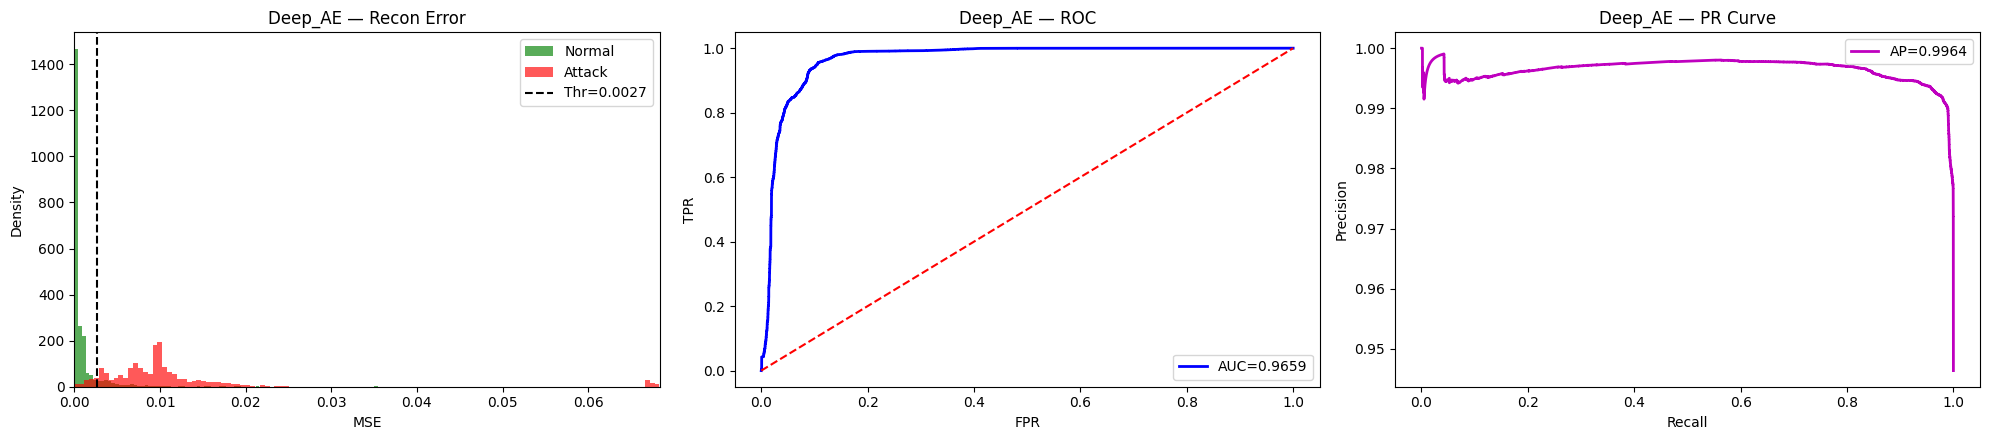

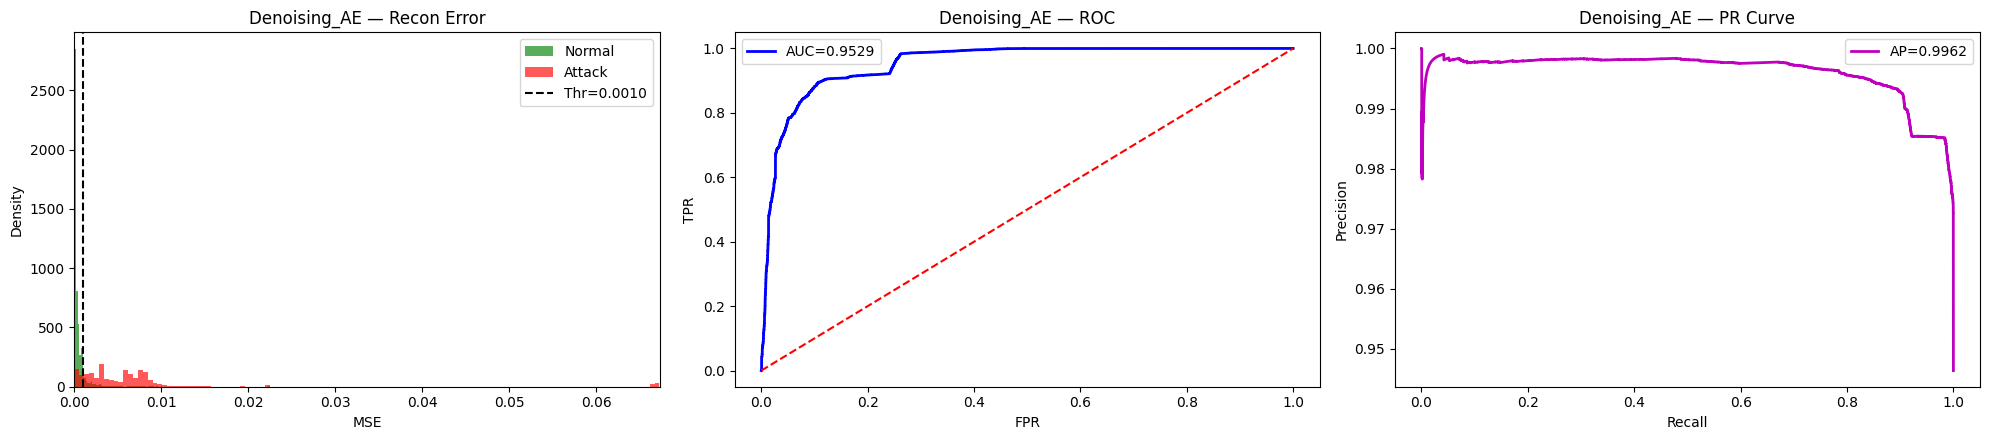

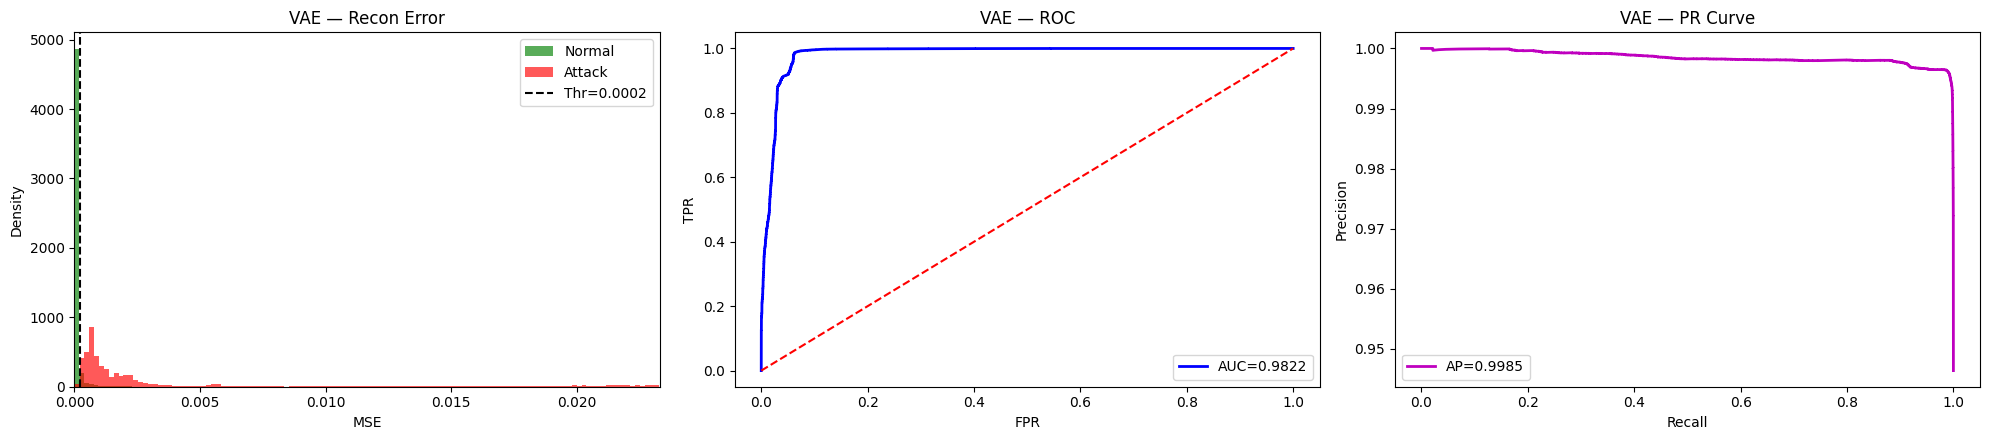

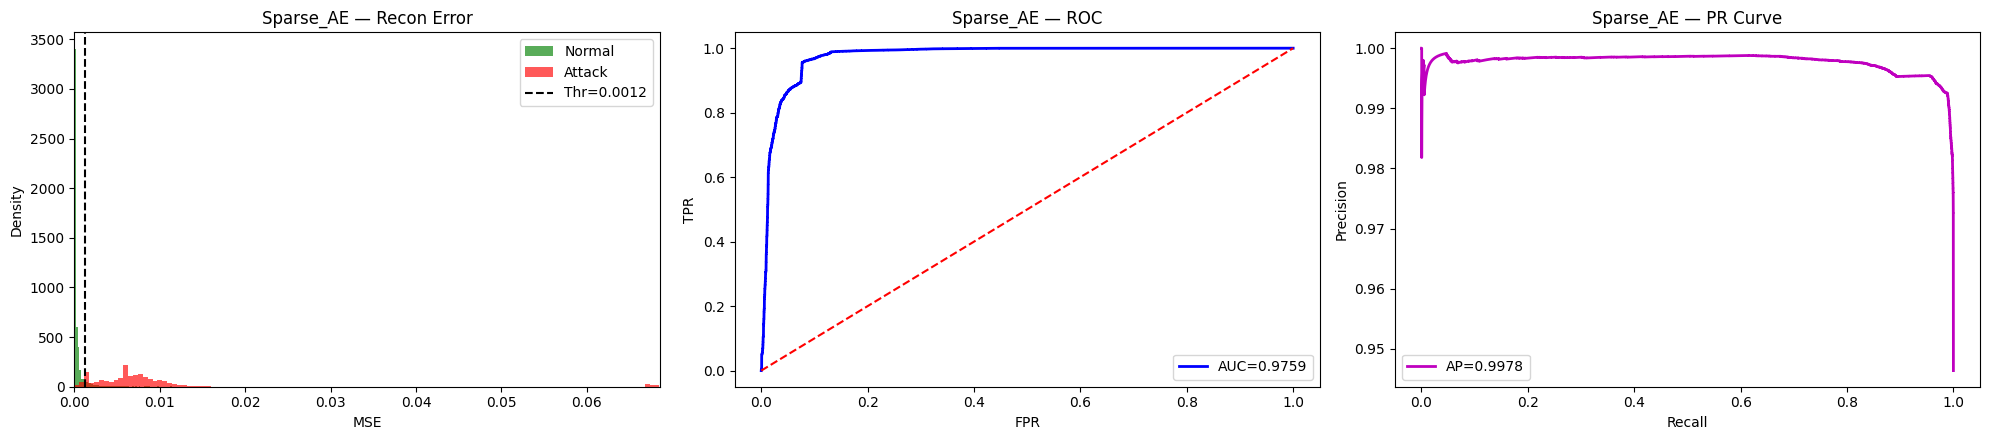

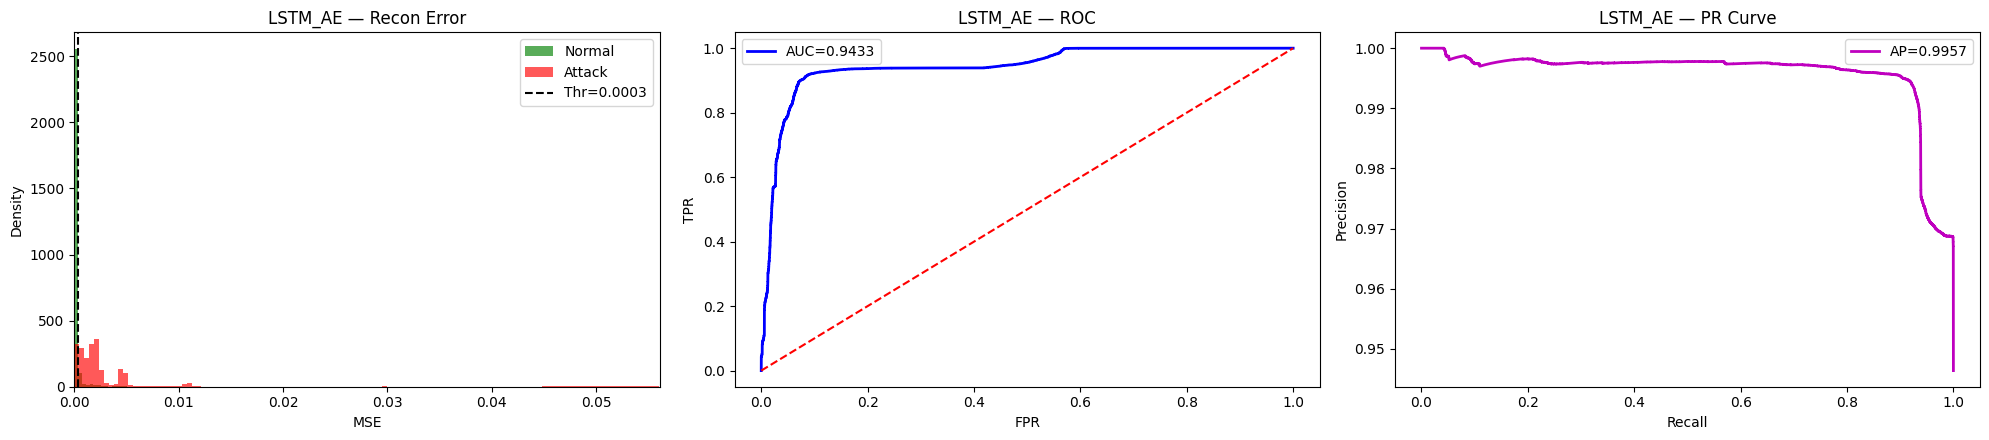

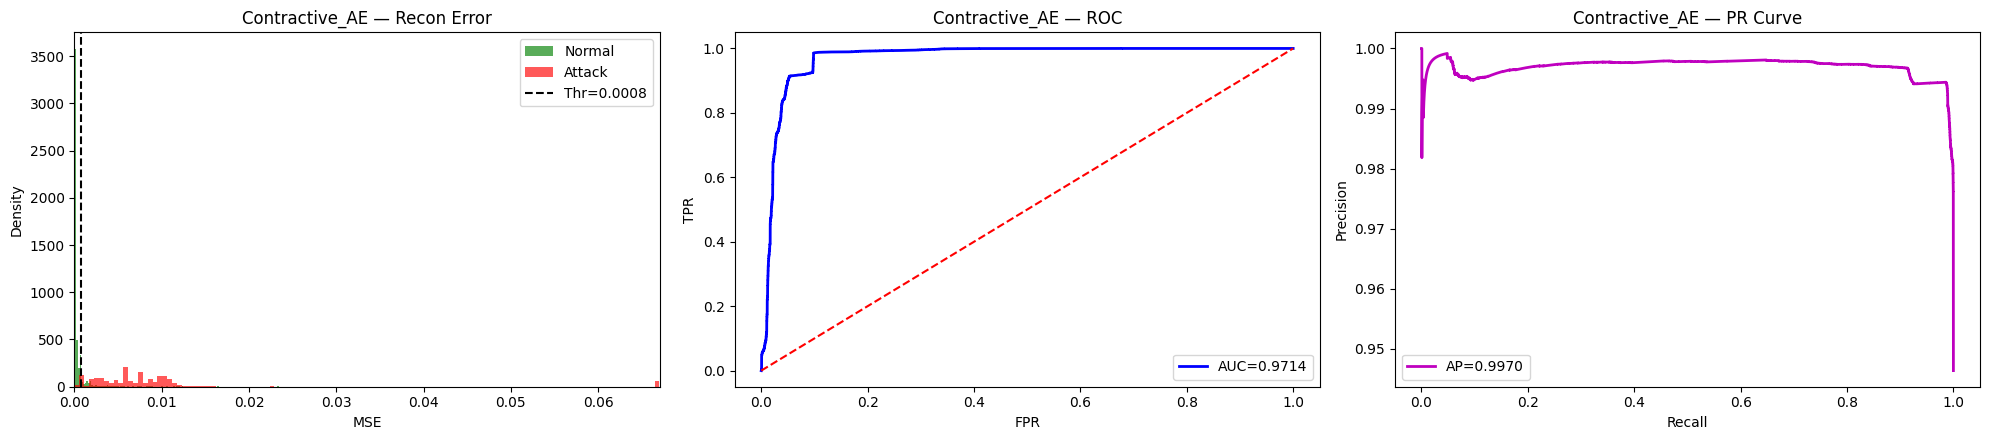

✅ Cell 14 Complete


In [14]:
# ============================================================
#  CELL 14: Reconstruction Error + ROC + PR for each model
# ============================================================
for name in trained_models:
    errs, th = all_errors[name]
    plot_model_results(errs, y_test, name, th)

print("✅ Cell 14 Complete")


     PHASE 1 RESULTS — CENTRALIZED AUTOENCODER COMPARISON
         Model  Accuracy  Precision  Recall     F1  AUC_ROC     AP
           VAE    0.9861     0.9962  0.9891 0.9926   0.9822 0.9985
Contractive_AE    0.9821     0.9942  0.9868 0.9905   0.9714 0.9970
     Sparse_AE    0.9576     0.9952  0.9599 0.9772   0.9759 0.9978
       Deep_AE    0.9359     0.9942  0.9377 0.9651   0.9659 0.9964
       LSTM_AE    0.9140     0.9947  0.9139 0.9526   0.9433 0.9957
  Denoising_AE    0.8826     0.9936  0.8817 0.9343   0.9529 0.9962

🏆 Best Centralized (by F1): VAE (F1=0.9926)


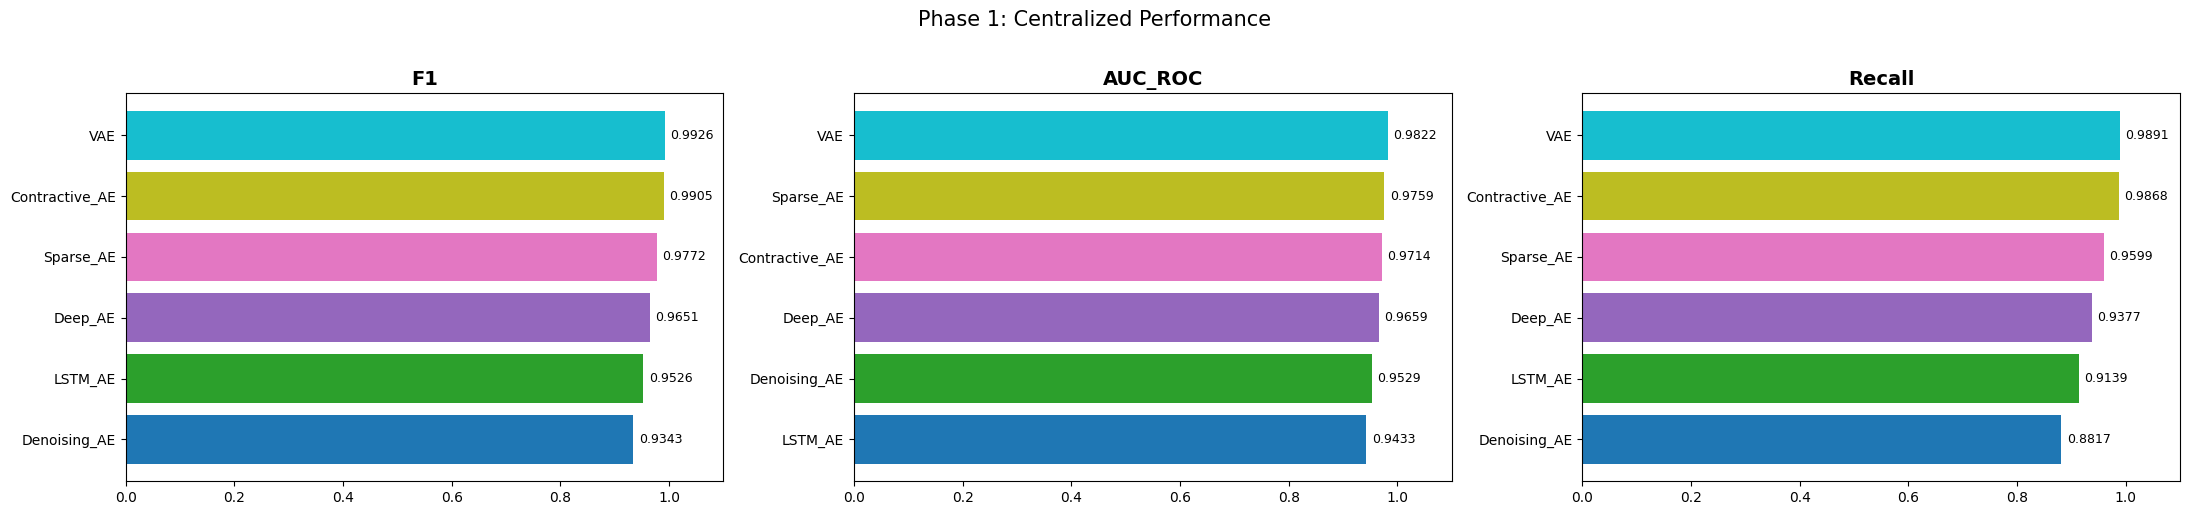

✅ Cell 15 Complete


In [15]:
# ============================================================
#  CELL 15: Centralized Model Comparison — Table + Bar Charts
# ============================================================

# Table
print("\n" + "=" * 90)
print("     PHASE 1 RESULTS — CENTRALIZED AUTOENCODER COMPARISON")
print("=" * 90)
display_cols = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1', 'AUC_ROC', 'AP']
print(df_results[display_cols].to_string(index=False, float_format='%.4f'))

best_central_name = df_results.iloc[0]['Model']
print(f"\n🏆 Best Centralized (by F1): {best_central_name} "
      f"(F1={df_results.iloc[0]['F1']:.4f})")

# Bar Charts
fig, axes = plt.subplots(1, 3, figsize=(22, 5))
metrics_bar = ['F1', 'AUC_ROC', 'Recall']
colors = plt.cm.tab10(np.linspace(0, 1, len(df_results)))

for ax, met in zip(axes, metrics_bar):
    vals = df_results.sort_values(met, ascending=True)
    ax.barh(vals['Model'], vals[met], color=colors)
    ax.set_title(met, fontsize=14, fontweight='bold')
    ax.set_xlim(0, 1.1)
    for i, v in enumerate(vals[met]):
        ax.text(v + 0.01, i, f'{v:.4f}', va='center', fontsize=9)

plt.suptitle('Phase 1: Centralized Performance', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()
print("✅ Cell 15 Complete")

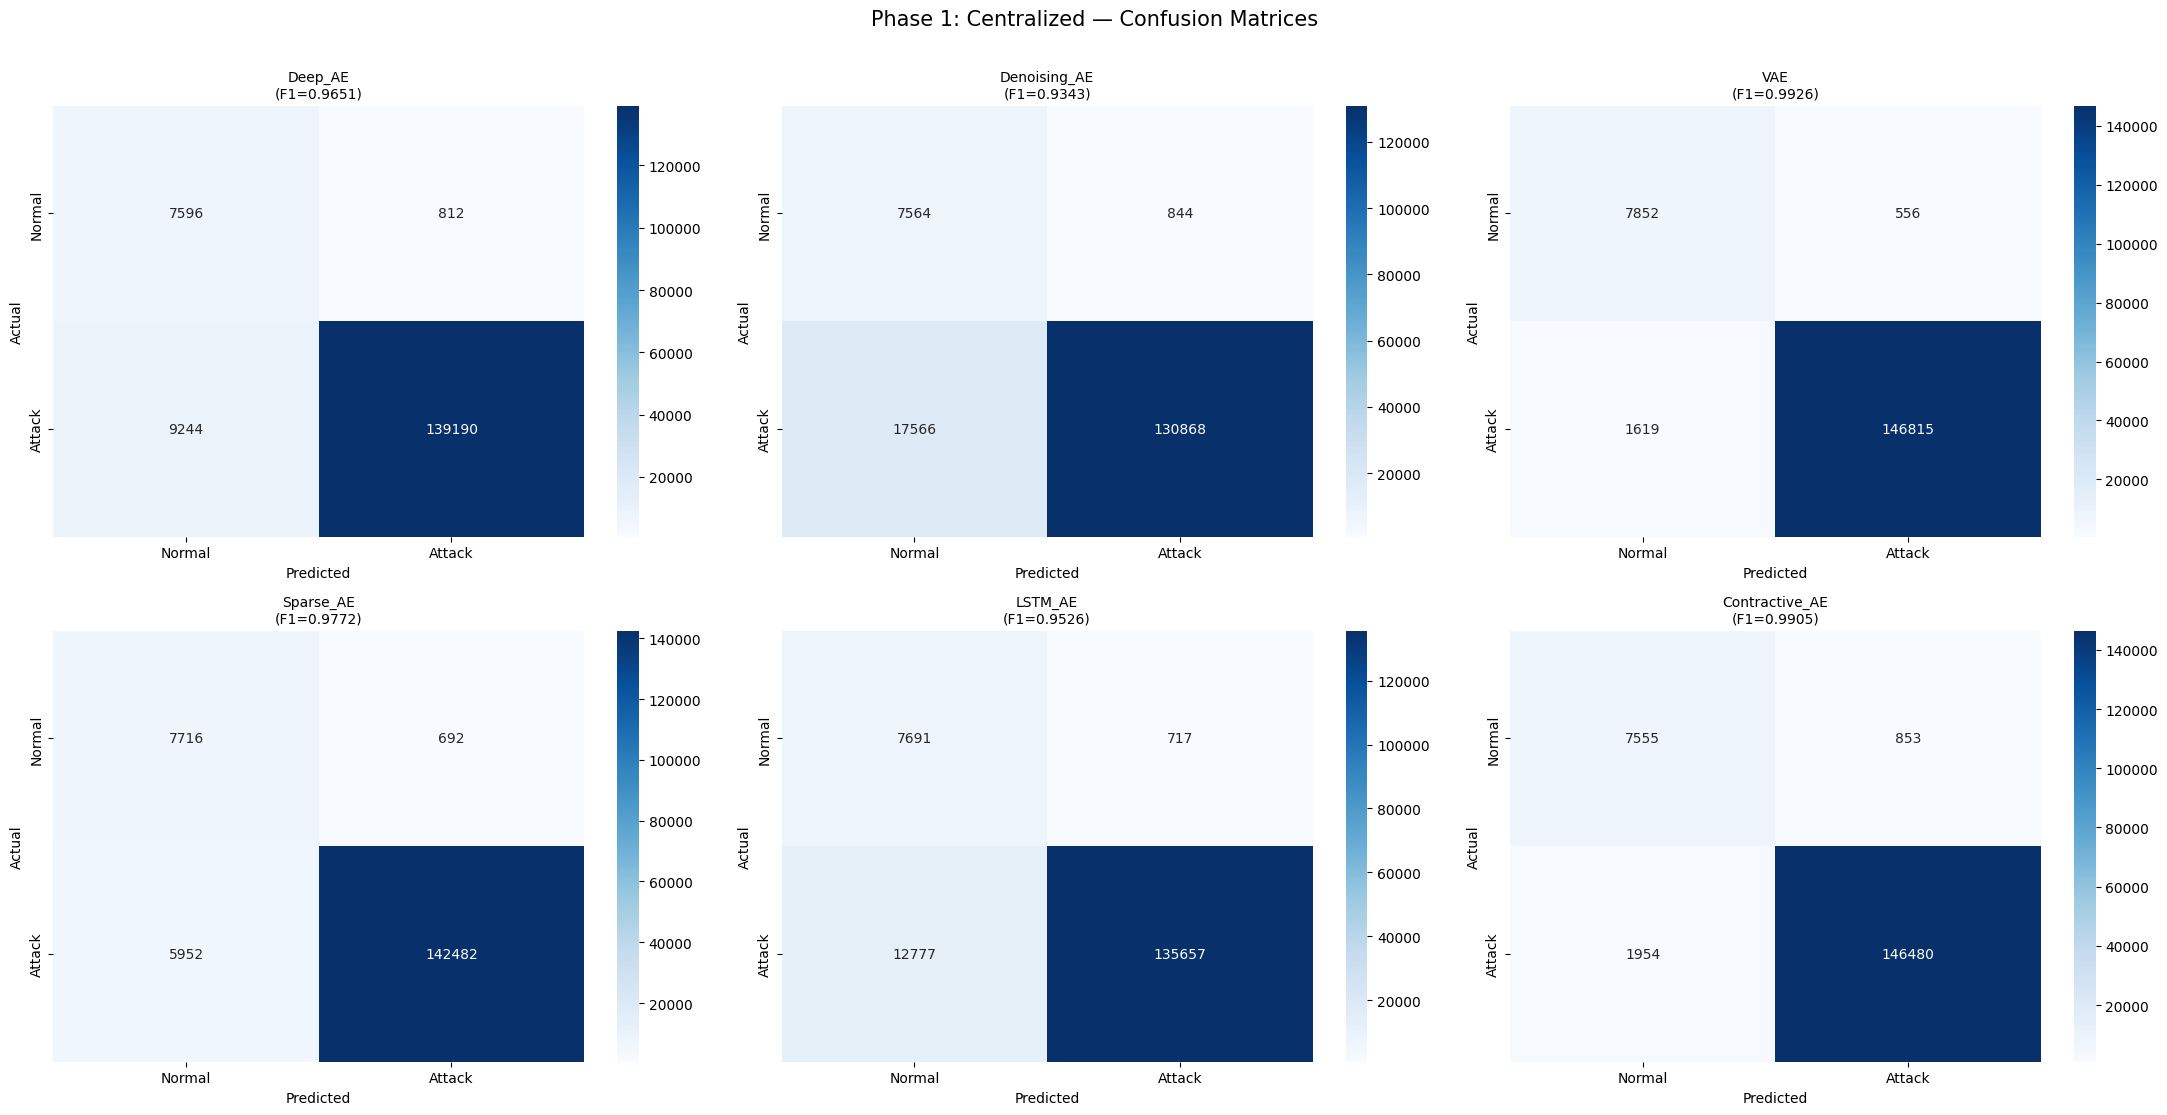

✅ Cell 16 Complete


In [16]:
# ============================================================
#  CELL 16: Centralized — Confusion Matrices
# ============================================================
NUM_MODELS = len(trained_models)
ncols = 3
nrows = (NUM_MODELS + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(22, 5.5 * nrows))
axes = axes.ravel()

for idx, name in enumerate(trained_models):
    errs, th = all_errors[name]
    y_pred = (errs > th).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    f1_val = f1_score(y_test, y_pred, zero_division=0)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Normal', 'Attack'],
                yticklabels=['Normal', 'Attack'], ax=axes[idx])
    axes[idx].set_title(f'{name}\n(F1={f1_val:.4f})', fontsize=10)
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

for j in range(idx + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Phase 1: Centralized — Confusion Matrices',
             fontsize=15, y=1.01)
plt.tight_layout()
plt.show()
print("✅ Cell 16 Complete")

In [17]:
# ============================================================
#  CELL 17: Federated Learning Engine
#  KEY: Initializes from PRE-TRAINED centralized weights
# ============================================================

class FederatedAnomalyDetector:
    """
    FedAvg for Autoencoders — Pre-trained Initialization.

    Pipeline:
      1. Receive centrally-trained model weights
      2. Use as initial global weights (NOT random)
      3. Split normal data among N clients
      4. Each round: broadcast → local train → collect → average
      5. Compare: Before FL vs After FL
    """

    def __init__(self, model_builder, input_dim,
                 pretrained_model=None,
                 num_clients=5, num_rounds=10,
                 local_epochs=100, batch_size=256):

        self.builder = model_builder
        self.input_dim = input_dim
        self.num_clients = num_clients
        self.num_rounds = num_rounds
        self.local_epochs = local_epochs
        self.batch_size = batch_size
        self.history = {'round': [], 'avg_client_loss': [], 'val_loss': []}

        # Build global model
        K.clear_session()
        self.global_model = self.builder(input_dim)

        # Load pre-trained weights if available
        if pretrained_model is not None:
            pretrained_weights = pretrained_model.get_weights()
            self.global_model.set_weights(pretrained_weights)

            # Verify transfer
            for i, (pw, gw) in enumerate(
                zip(pretrained_weights, self.global_model.get_weights())
            ):
                assert np.allclose(pw, gw), f"Weight mismatch at layer {i}!"

            print(f"  ✅ Initialized with PRE-TRAINED weights "
                  f"({len(pretrained_weights)} arrays copied)")
        else:
            print(f"  ⚠️  No pretrained model — starting RANDOM")

    # ── IID Partitioning ──
    def partition_data_iid(self, X):
        idx = np.random.permutation(len(X))
        splits = np.array_split(idx, self.num_clients)
        return [X[s] for s in splits]

    # ── Non-IID Partitioning ──
    def partition_data_noniid(self, X, alpha=0.5):
        proportions = np.random.dirichlet([alpha] * self.num_clients)
        splits = (proportions * len(X)).astype(int)
        splits[-1] = len(X) - splits[:-1].sum()
        idx = np.random.permutation(len(X))
        parts, start = [], 0
        for s in splits:
            parts.append(X[idx[start:start + s]])
            start += s
        return parts

    # ── FedAvg Aggregation ──
    @staticmethod
    def fedavg(client_weights, client_sizes):
        total = sum(client_sizes)
        avg_w = []
        for layer_i in range(len(client_weights[0])):
            w = np.zeros_like(client_weights[0][layer_i])
            for c in range(len(client_weights)):
                w += (client_sizes[c] / total) * client_weights[c][layer_i]
            avg_w.append(w)
        return avg_w

    # ── One FL Round ──
    def _train_one_round(self, client_data):
        global_w = self.global_model.get_weights()
        client_ws, client_ns = [], []

        for ci in range(self.num_clients):
            K.clear_session()
            gc.collect()

            local_model = self.builder(self.input_dim)
            local_model.set_weights(global_w)

            local_model.fit(
                client_data[ci], client_data[ci],
                epochs=self.local_epochs,
                batch_size=self.batch_size,
                verbose=0
            )

            client_ws.append(local_model.get_weights())
            client_ns.append(len(client_data[ci]))
            del local_model
            gc.collect()

        # Aggregate
        new_w = self.fedavg(client_ws, client_ns)

        K.clear_session()
        self.global_model = self.builder(self.input_dim)
        self.global_model.set_weights(new_w)

        # Average loss across clients
        avg_loss = np.mean([
            self.global_model.evaluate(
                client_data[c], client_data[c], verbose=0)
            for c in range(self.num_clients)
        ])
        return avg_loss

    # ── Full FL Training ──
    def train(self, X_train, X_val=None, partition='iid'):
        if partition == 'iid':
            client_data = self.partition_data_iid(X_train)
        else:
            client_data = self.partition_data_noniid(X_train)

        # Initial loss BEFORE any FL round
        init_loss = self.global_model.evaluate(X_val, X_val, verbose=0)
        if isinstance(init_loss, list):
            init_loss = init_loss[0]

        print(f"\n{'=' * 72}")
        print(f"  Federated Training (PRE-TRAINED START)")
        print(f"  Clients: {self.num_clients} | Rounds: {self.num_rounds} "
              f"| Local Epochs: {self.local_epochs}")
        print(f"  Batch size: {self.batch_size}")
        print(f"  Client sizes: {[len(c) for c in client_data]}")
        print(f"  Initial Val Loss (from pretrained): {init_loss:.6f}")
        print(f"{'=' * 72}")

        for rnd in range(1, self.num_rounds + 1):
            t0 = time.time()
            avg_loss = self._train_one_round(client_data)

            val_loss = (self.global_model.evaluate(X_val, X_val, verbose=0)
                        if X_val is not None else avg_loss)
            if isinstance(val_loss, list):
                val_loss = val_loss[0]
            if isinstance(avg_loss, (list, np.ndarray)):
                avg_loss = float(np.mean(avg_loss))

            dt = time.time() - t0

            self.history['round'].append(rnd)
            self.history['avg_client_loss'].append(avg_loss)
            self.history['val_loss'].append(val_loss)

            improvement = ((init_loss - val_loss) / max(init_loss, 1e-10)) * 100
            arrow = "📈" if improvement > 0 else "📉"

            print(f"  Round {rnd:>2}/{self.num_rounds} │ "
                  f"Client: {avg_loss:.6f} │ "
                  f"Val: {val_loss:.6f} │ "
                  f"{arrow} {improvement:+.2f}% vs pretrained │ "
                  f"⏱ {dt:.1f}s")

        final_loss = self.history['val_loss'][-1]
        change = ((init_loss - final_loss) / max(init_loss, 1e-10)) * 100
        print(f"\n  {'─' * 55}")
        print(f"  Pre-trained Loss : {init_loss:.6f}")
        print(f"  After FL Loss    : {final_loss:.6f}")
        print(f"  Change           : {change:+.2f}%")
        if change > 0:
            print(f"  ✅ FL IMPROVED the model by {change:.2f}%!")
        else:
            print(f"  ⚠️  FL did not improve (model already optimal)")
        print(f"  {'─' * 55}")

        return self.global_model

print("✅ Cell 17 Complete — FL Engine ready")

✅ Cell 17 Complete — FL Engine ready


In [18]:
# ============================================================
#  CELL 18: PHASE 2 — Federated Learning (Pre-trained Start)
#  Uses centrally trained weights from Phase 1
# ============================================================

NUM_CLIENTS = 5
NUM_ROUNDS = 10
LOCAL_EPOCHS = 100

fl_models = {}
fl_histories = {}

for name, builder in BUILDERS.items():
    print(f"\n{'#' * 75}")
    print(f"  FL Training ▸ {name}")
    print(f"  Starting from CENTRALLY TRAINED weights")
    print(f"{'#' * 75}")

    K.clear_session()
    gc.collect()

    fl = FederatedAnomalyDetector(
        model_builder=builder,
        input_dim=INPUT_DIM,
        pretrained_model=trained_models[name],  # ← Pre-trained!
        num_clients=NUM_CLIENTS,
        num_rounds=NUM_ROUNDS,
        local_epochs=LOCAL_EPOCHS,
        batch_size=BATCH_SIZE
    )

    t0 = time.time()
    global_model = fl.train(
        X_normal_train, X_val=X_normal_val, partition='iid'
    )
    dt = time.time() - t0

    fl_models[name] = global_model
    fl_histories[name] = fl.history
    print(f"\n  ✅ {name} FL completed in {dt:.1f}s total")

print(f"\n✅ Cell 18 Complete — All 7 FL models trained")


###########################################################################
  FL Training ▸ Deep_AE
  Starting from CENTRALLY TRAINED weights
###########################################################################
  ✅ Initialized with PRE-TRAINED weights (32 arrays copied)

  Federated Training (PRE-TRAINED START)
  Clients: 5 | Rounds: 10 | Local Epochs: 100
  Batch size: 256
  Client sizes: [6727, 6727, 6726, 6726, 6726]
  Initial Val Loss (from pretrained): 0.001126
  Round  1/10 │ Client: 0.000775 │ Val: 0.000791 │ 📈 +29.73% vs pretrained │ ⏱ 116.0s
  Round  2/10 │ Client: 0.000664 │ Val: 0.000697 │ 📈 +38.08% vs pretrained │ ⏱ 116.0s
  Round  3/10 │ Client: 0.000619 │ Val: 0.000655 │ 📈 +41.85% vs pretrained │ ⏱ 118.2s
  Round  4/10 │ Client: 0.000592 │ Val: 0.000628 │ 📈 +44.21% vs pretrained │ ⏱ 119.7s
  Round  5/10 │ Client: 0.000576 │ Val: 0.000612 │ 📈 +45.66% vs pretrained │ ⏱ 120.8s
  Round  6/10 │ Client: 0.000554 │ Val: 0.000587 │ 📈 +47.84% vs pretrained │ ⏱ 122.8s
  Rou

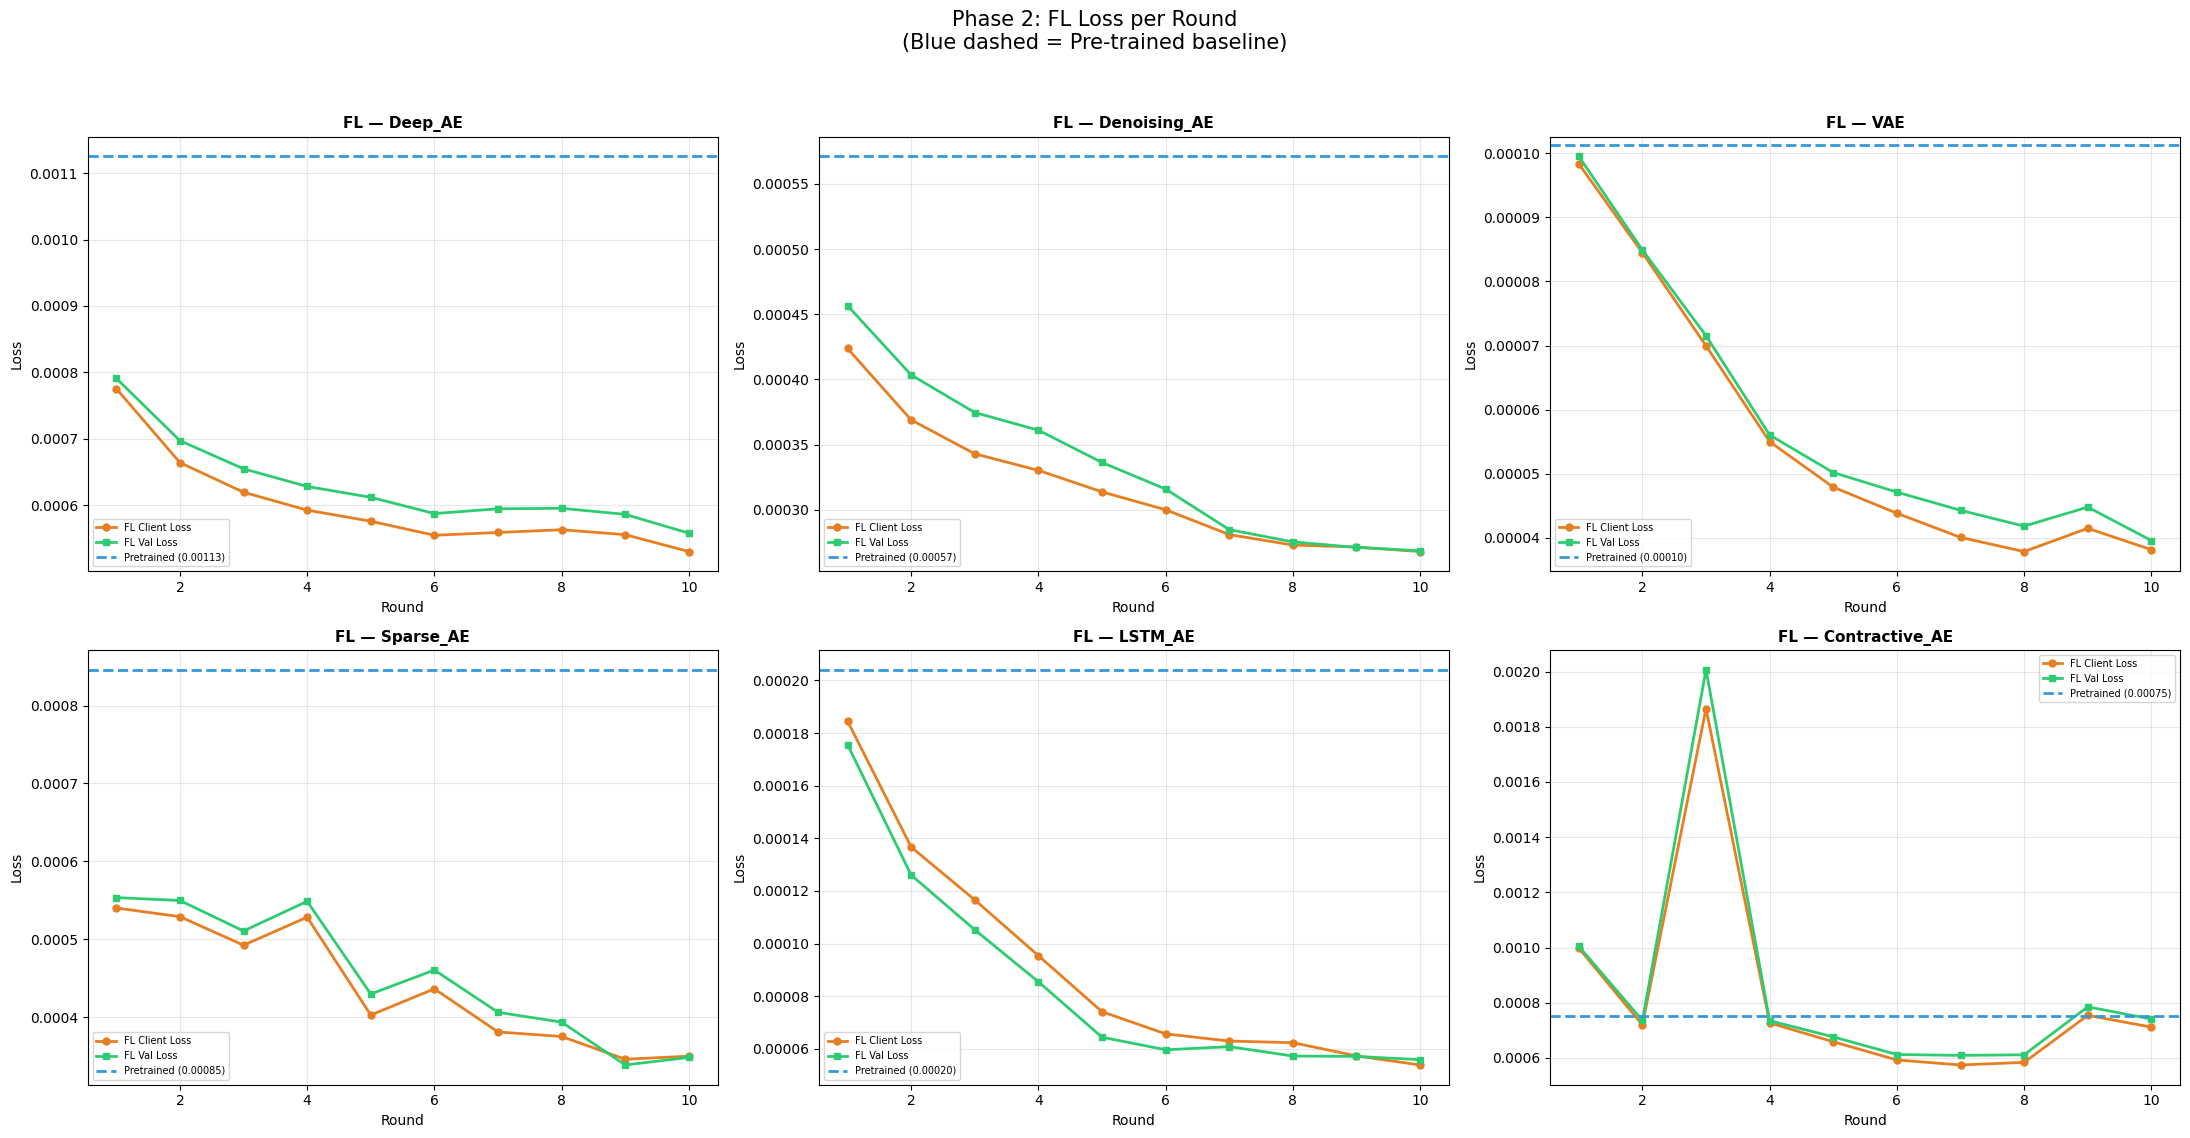

✅ Cell 19 Complete


In [19]:
# ============================================================
#  CELL 19: FL Loss Curves with Pre-trained Baseline
# ============================================================
NUM_MODELS = len(fl_histories)
ncols = 3
nrows = (NUM_MODELS + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(22, 5.5 * nrows))
axes = axes.ravel()

for idx, (name, h) in enumerate(fl_histories.items()):
    ax = axes[idx]

    ax.plot(h['round'], h['avg_client_loss'], 'o-',
            color='#e67e22', lw=2, ms=5, label='FL Client Loss')
    ax.plot(h['round'], h['val_loss'], 's-',
            color='#2ecc71', lw=2, ms=5, label='FL Val Loss')

    pretrained_val = train_histories[name]['val_loss'][-1]
    ax.axhline(y=pretrained_val, color='#3498db', ls='--', lw=2,
               label=f'Pretrained ({pretrained_val:.5f})')

    ax.set_title(f'FL — {name}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Round')
    ax.set_ylabel('Loss')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

for j in range(idx + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Phase 2: FL Loss per Round\n'
             '(Blue dashed = Pre-trained baseline)',
             fontsize=15, y=1.03)
plt.tight_layout()
plt.show()
print("✅ Cell 19 Complete")

In [20]:
# ============================================================
#  CELL 20: Evaluate All FL-Refined Models
# ============================================================

fl_results = []
fl_all_errors = {}

for name, model in fl_models.items():
    res, errs = evaluate_autoencoder(
        model, X_test, y_test,
        X_normal_val, X_attack_sample,
        name=f'FL_{name}'
    )
    fl_results.append(res)
    fl_all_errors[name] = (errs, res['Threshold'])

df_fl = pd.DataFrame(fl_results).sort_values('F1', ascending=False)

print(f"\n✅ Cell 20 Complete — All FL models evaluated")


   FL_Deep_AE
   Accuracy    : 0.9813
   Precision   : 0.9948
   Recall      : 0.9854
   F1          : 0.9901
   AUC_ROC     : 0.9725
   AP          : 0.9973
   Threshold   : 0.001070

   FL_Denoising_AE
   Accuracy    : 0.8763
   Precision   : 0.9964
   Recall      : 0.8725
   F1          : 0.9303
   AUC_ROC     : 0.9562
   AP          : 0.9970
   Threshold   : 0.000714

   FL_VAE
   Accuracy    : 0.9728
   Precision   : 0.9967
   Recall      : 0.9745
   F1          : 0.9855
   AUC_ROC     : 0.9858
   AP          : 0.9989
   Threshold   : 0.000085

   FL_Sparse_AE
   Accuracy    : 0.8770
   Precision   : 0.9964
   Recall      : 0.8732
   F1          : 0.9308
   AUC_ROC     : 0.9629
   AP          : 0.9970
   Threshold   : 0.000950

   FL_LSTM_AE
   Accuracy    : 0.9825
   Precision   : 0.9966
   Recall      : 0.9849
   F1          : 0.9907
   AUC_ROC     : 0.9838
   AP          : 0.9986
   Threshold   : 0.000072

   FL_Contractive_AE
   Accuracy    : 0.9311
   Precision   : 0.9958
  

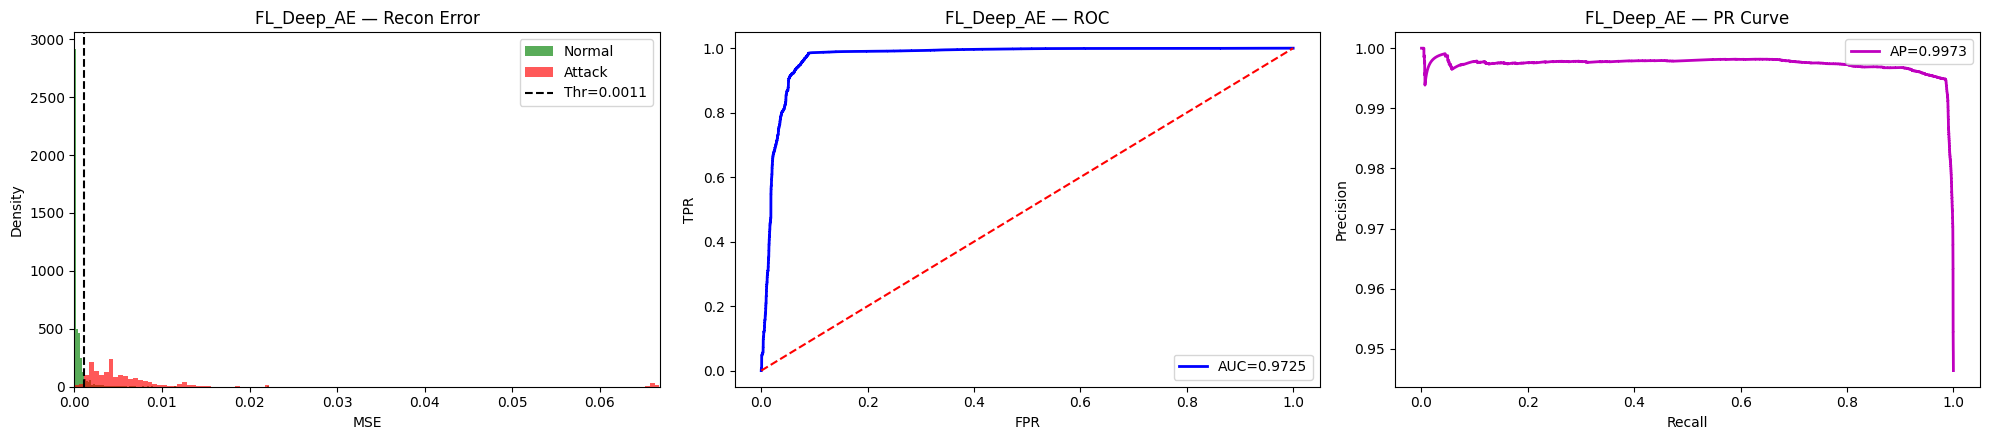

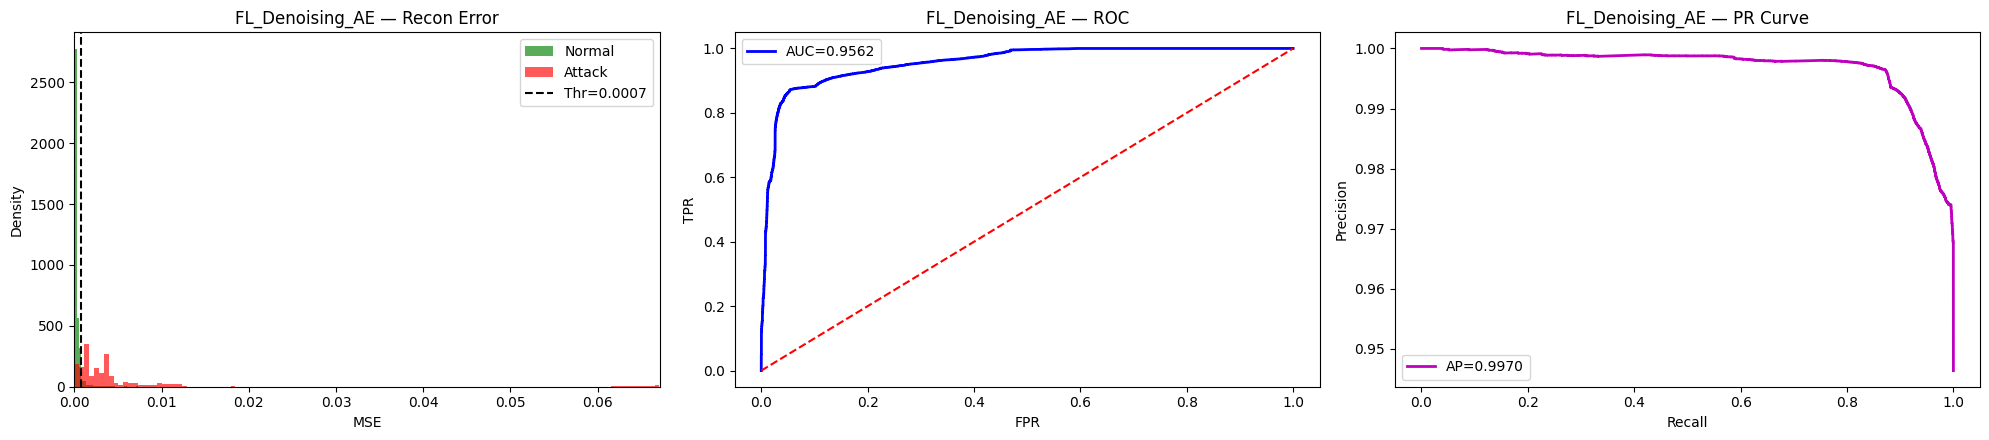

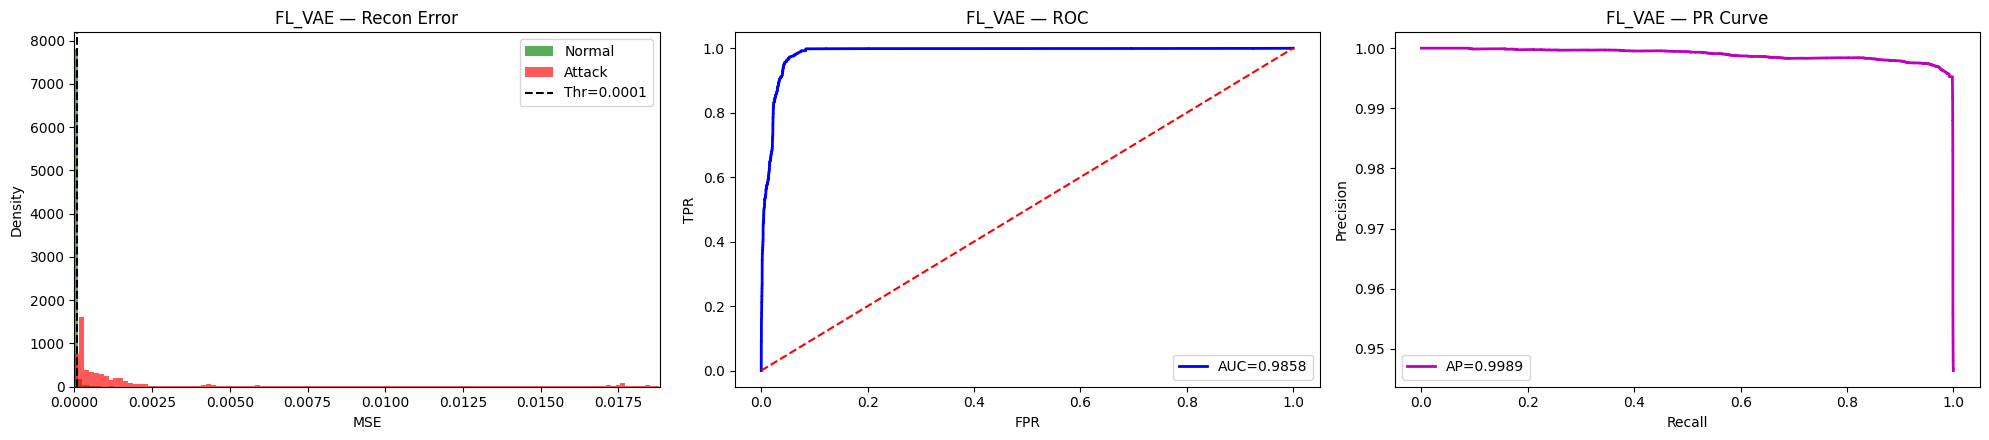

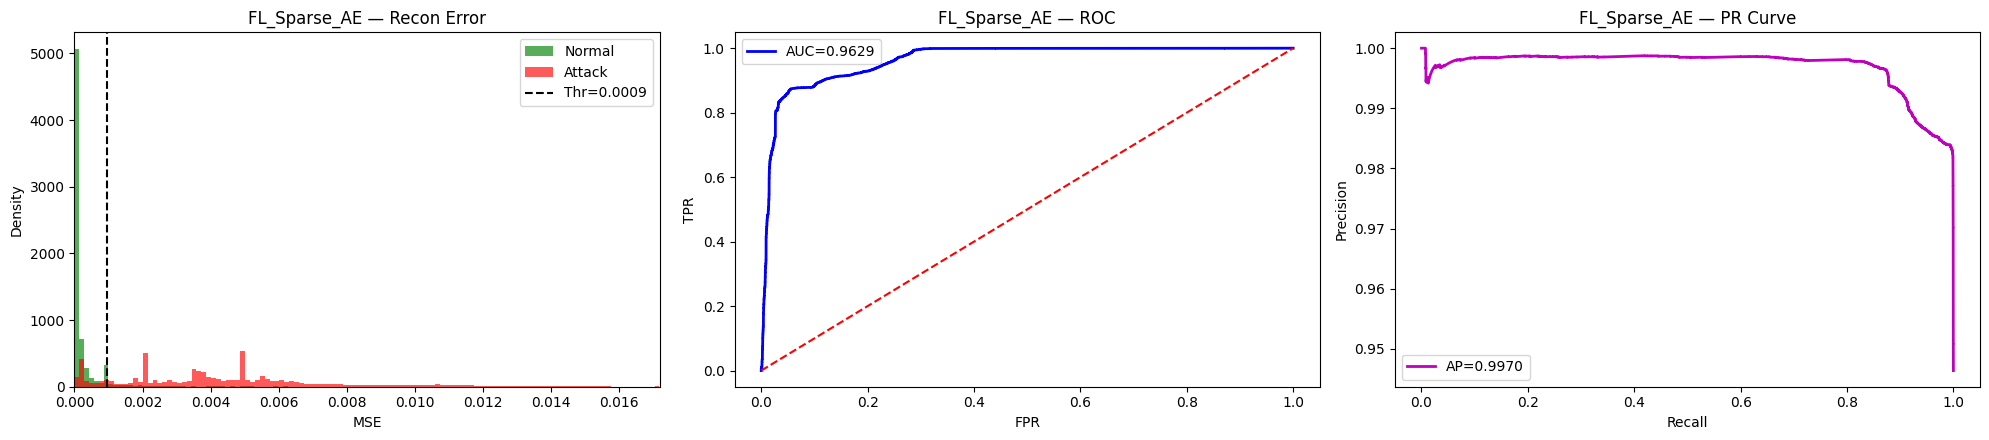

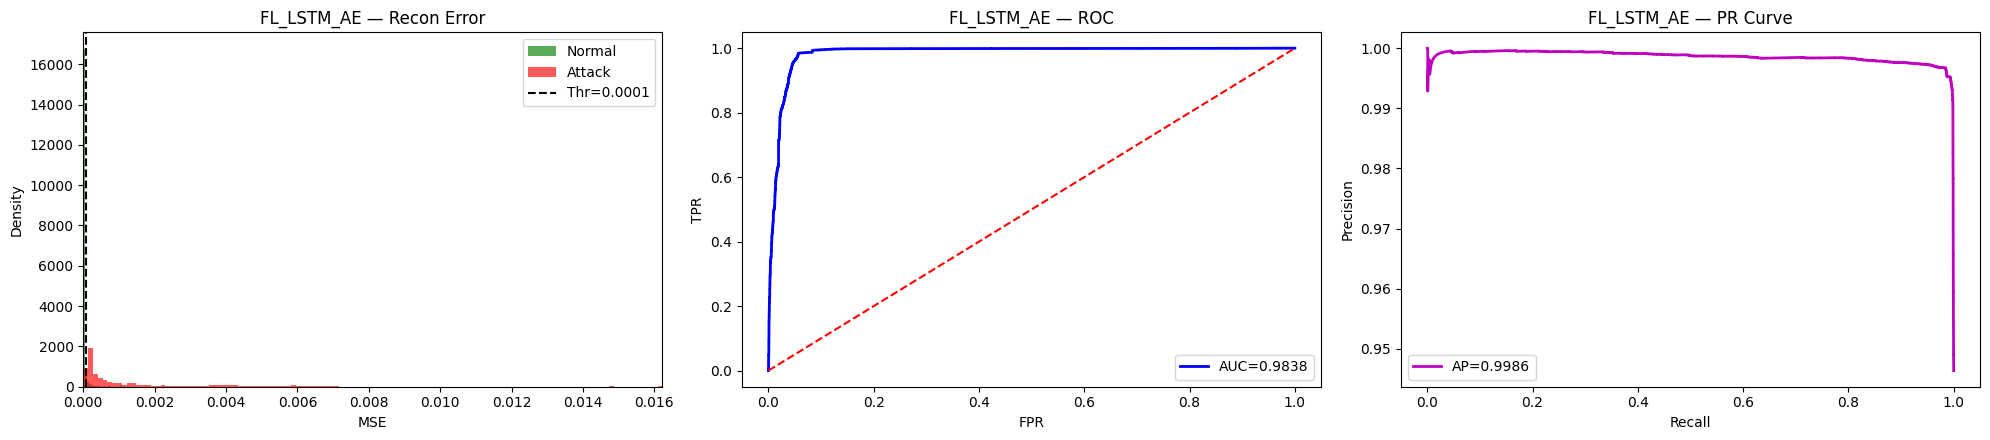

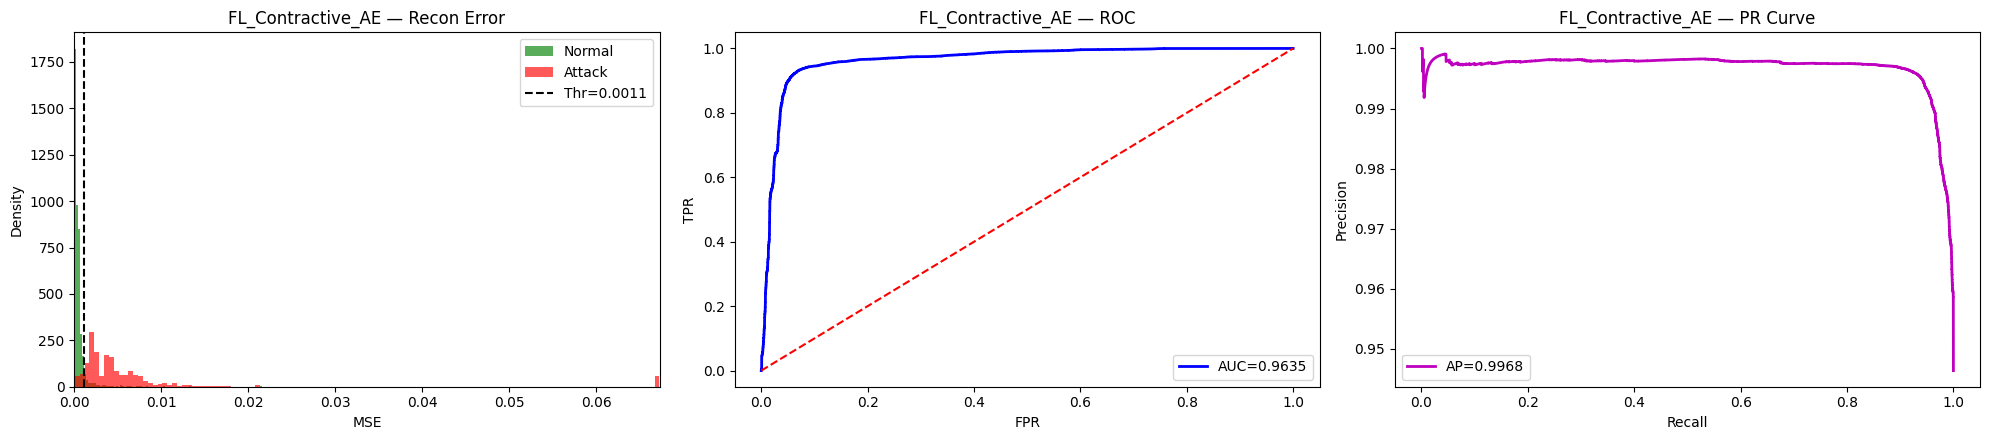

✅ Cell 21 Complete


In [21]:
# ============================================================
#  CELL 21: FL Models — Reconstruction Error + ROC + PR
# ============================================================
for name in fl_models:
    errs, th = fl_all_errors[name]
    plot_model_results(errs, y_test, f'FL_{name}', th)

print("✅ Cell 21 Complete")

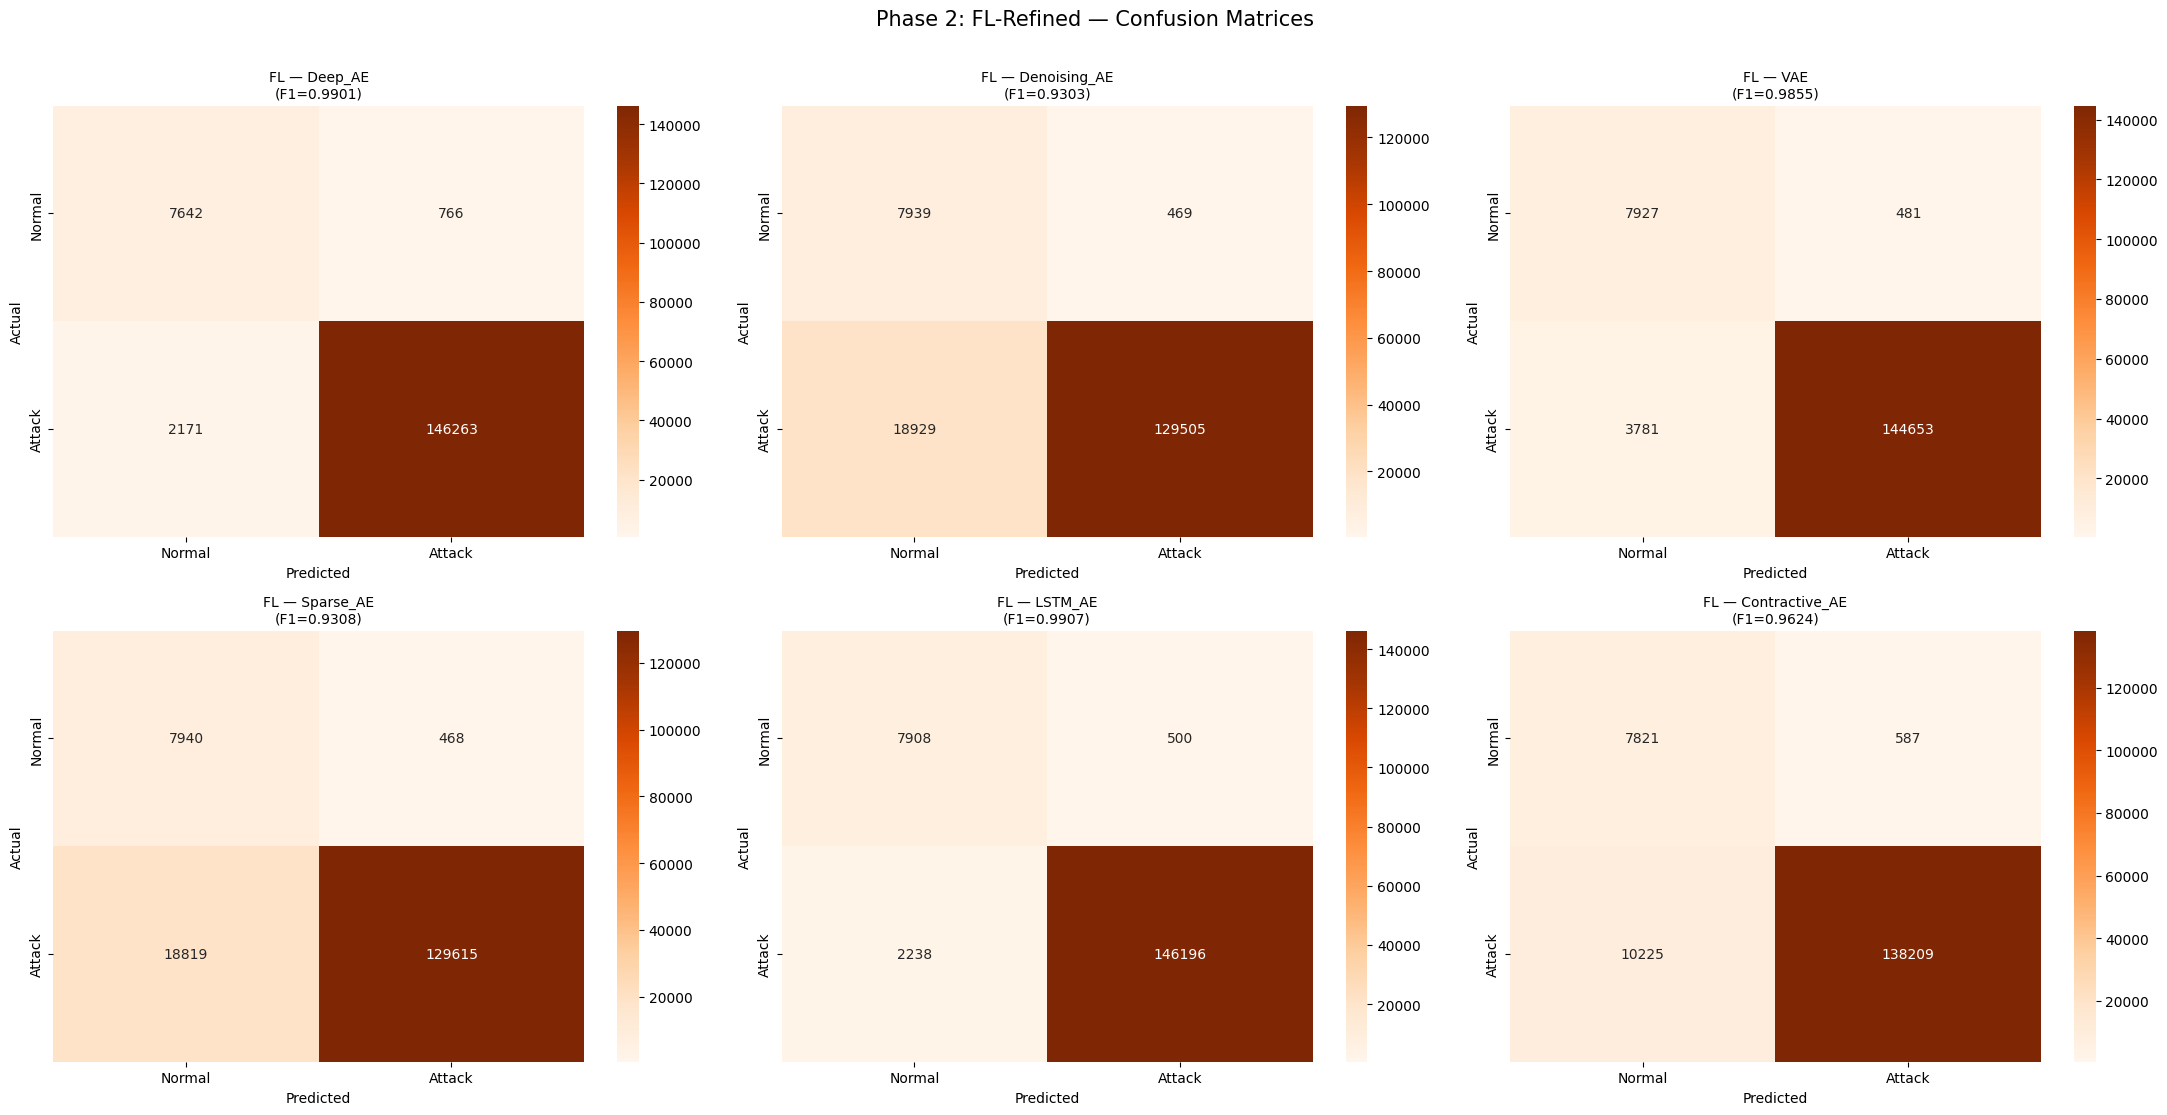

✅ Cell 22 Complete


In [22]:
# ============================================================
#  CELL 22: FL Models — Confusion Matrices
# ============================================================
NUM_MODELS = len(fl_models)
ncols = 3
nrows = (NUM_MODELS + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(22, 5.5 * nrows))
axes = axes.ravel()

for idx, name in enumerate(fl_models):
    errs, th = fl_all_errors[name]
    y_pred = (errs > th).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    f1_val = f1_score(y_test, y_pred, zero_division=0)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
                xticklabels=['Normal', 'Attack'],
                yticklabels=['Normal', 'Attack'], ax=axes[idx])
    axes[idx].set_title(f'FL — {name}\n(F1={f1_val:.4f})', fontsize=10)
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

for j in range(idx + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Phase 2: FL-Refined — Confusion Matrices',
             fontsize=15, y=1.01)
plt.tight_layout()
plt.show()
print("✅ Cell 22 Complete")

In [ ]:
# ============================================================
#  CELL 23: PHASE 3 — Before FL vs After FL Comparison
# ============================================================

print("=" * 100)
print("  🏆  PHASE 3: BEFORE FL (Centralized)  vs  AFTER FL (Refined)")
print("  Same model architecture — only difference is FL refinement")
print("=" * 100)

print(f"\n  {'Model':<18} │ {'Metric':<12} │ {'Before FL':>11} │ "
      f"{'After FL':>11} │ {'Change':>10} │ {'Winner':>12}")
print(f"  {'─' * 18}─┼─{'─' * 12}─┼─{'─' * 11}─┼─"
      f"{'─' * 11}─┼─{'─' * 10}─┼─{'─' * 12}")

comparison_data = []

for name in BUILDERS.keys():
    central_row = df_results[df_results['Model'] == name].iloc[0]
    fl_row = df_fl[df_fl['Model'] == f'FL_{name}'].iloc[0]

    for metric in ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC_ROC']:
        c_val = central_row[metric]
        f_val = fl_row[metric]
        change = f_val - c_val

        if change > 0.001:
            winner = "After FL ✅"
        elif change < -0.001:
            winner = "Before FL ✅"
        else:
            winner = "Tie 🤝"

        print(f"  {name:<18} │ {metric:<12} │ {c_val:>11.4f} │ "
              f"{f_val:>11.4f} │ {change:>+10.4f} │ {winner:>12}")

        comparison_data.append({
            'Model': name, 'Metric': metric,
            'Before_FL': c_val, 'After_FL': f_val,
            'Change': change, 'Winner': winner
        })

    print(f"  {'─' * 18}─┼─{'─' * 12}─┼─{'─' * 11}─┼─"
          f"{'─' * 11}─┼─{'─' * 10}─┼─{'─' * 12}")

df_comparison = pd.DataFrame(comparison_data)
print("\n✅ Cell 23 Complete")

  🏆  PHASE 3: BEFORE FL (Centralized)  vs  AFTER FL (Refined)
  Same model architecture — only difference is FL refinement

  Model              │ Metric       │   Before FL │    After FL │     Change │       Winner
  ───────────────────┼──────────────┼─────────────┼─────────────┼────────────┼─────────────
  Deep_AE            │ Accuracy     │      0.9359 │      0.9813 │    +0.0454 │   After FL ✅
  Deep_AE            │ Precision    │      0.9942 │      0.9948 │    +0.0006 │        Tie 🤝
  Deep_AE            │ Recall       │      0.9377 │      0.9854 │    +0.0477 │   After FL ✅
  Deep_AE            │ F1           │      0.9651 │      0.9901 │    +0.0249 │   After FL ✅
  Deep_AE            │ AUC_ROC      │      0.9659 │      0.9725 │    +0.0067 │   After FL ✅
  ───────────────────┼──────────────┼─────────────┼─────────────┼────────────┼─────────────
  Denoising_AE       │ Accuracy     │      0.8826 │      0.8763 │    -0.0063 │  Before FL ✅
  Denoising_AE       │ Precision    │      0.993

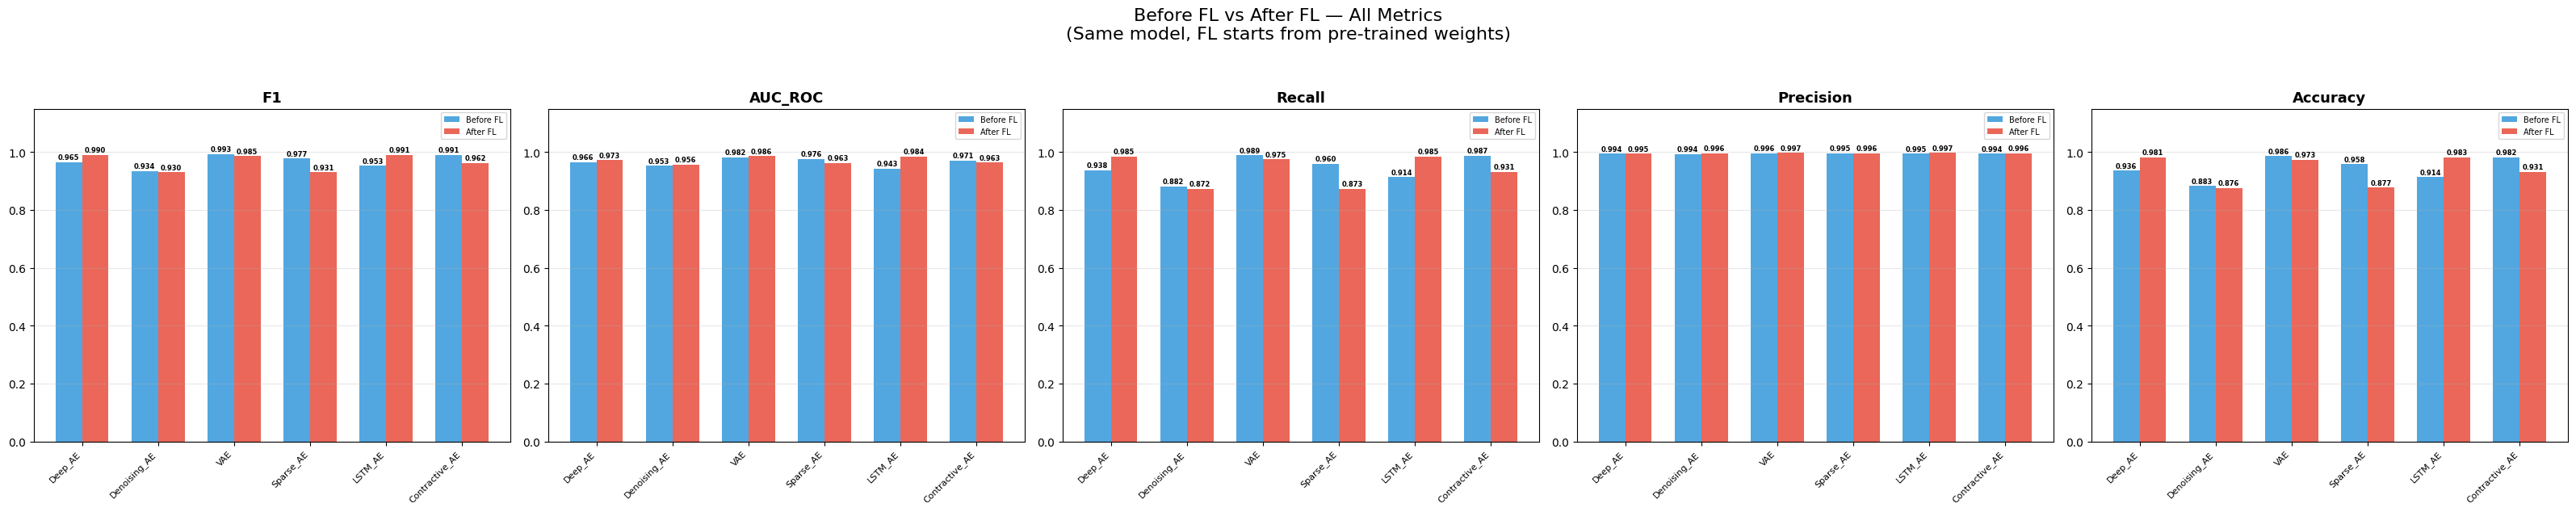

✅ Cell 24 Complete


In [ ]:
# ============================================================
#  CELL 24: Before FL vs After FL — Bar Charts
# ============================================================
model_names = list(BUILDERS.keys())
metrics_compare = ['F1', 'AUC_ROC', 'Recall', 'Precision', 'Accuracy']

fig, axes = plt.subplots(1, 5, figsize=(32, 6))
bar_w = 0.35
x = np.arange(len(model_names))

for ax, met in zip(axes, metrics_compare):
    c_vals = [df_results.loc[df_results['Model'] == n, met].values[0]
              for n in model_names]
    f_vals = [df_fl.loc[df_fl['Model'] == f'FL_{n}', met].values[0]
              for n in model_names]

    ax.bar(x - bar_w / 2, c_vals, bar_w,
           label='Before FL', color='#3498db', alpha=0.85)
    ax.bar(x + bar_w / 2, f_vals, bar_w,
           label='After FL', color='#e74c3c', alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=45, ha='right', fontsize=8)
    ax.set_title(met, fontsize=13, fontweight='bold')
    ax.set_ylim(0, 1.15)
    ax.legend(fontsize=7)
    ax.grid(axis='y', alpha=0.3)

    for i in range(len(model_names)):
        ax.text(i - bar_w / 2, c_vals[i] + 0.01, f'{c_vals[i]:.3f}',
                ha='center', fontsize=6, fontweight='bold')
        ax.text(i + bar_w / 2, f_vals[i] + 0.01, f'{f_vals[i]:.3f}',
                ha='center', fontsize=6, fontweight='bold')

plt.suptitle('Before FL vs After FL — All Metrics\n'
             '(Same model, FL starts from pre-trained weights)',
             fontsize=16, y=1.05)
plt.tight_layout()
plt.show()
print("✅ Cell 24 Complete")

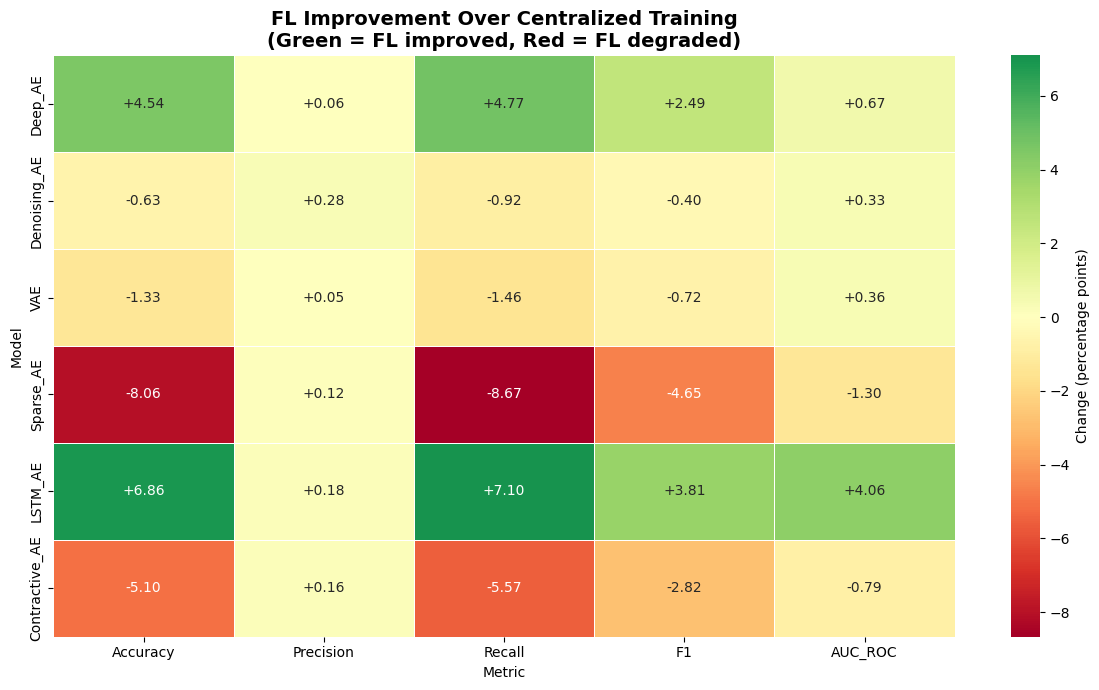

✅ Cell 25 Complete


In [ ]:
# ============================================================
#  CELL 25: Improvement Heatmap
#  Green = FL improved | Red = FL degraded
# ============================================================
model_names = list(BUILDERS.keys())
metrics_heat = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC_ROC']

improvement_matrix = np.zeros((len(model_names), len(metrics_heat)))

for i, name in enumerate(model_names):
    for j, met in enumerate(metrics_heat):
        c_val = df_results.loc[df_results['Model'] == name, met].values[0]
        f_val = df_fl.loc[df_fl['Model'] == f'FL_{name}', met].values[0]
        improvement_matrix[i, j] = (f_val - c_val) * 100

plt.figure(figsize=(12, 7))
sns.heatmap(improvement_matrix,
            xticklabels=metrics_heat,
            yticklabels=model_names,
            annot=True, fmt='+.2f', center=0,
            cmap='RdYlGn',
            linewidths=0.5,
            cbar_kws={'label': 'Change (percentage points)'})

plt.title('FL Improvement Over Centralized Training\n'
          '(Green = FL improved, Red = FL degraded)',
          fontsize=14, fontweight='bold')
plt.xlabel('Metric')
plt.ylabel('Model')
plt.tight_layout()
plt.show()
print("✅ Cell 25 Complete")

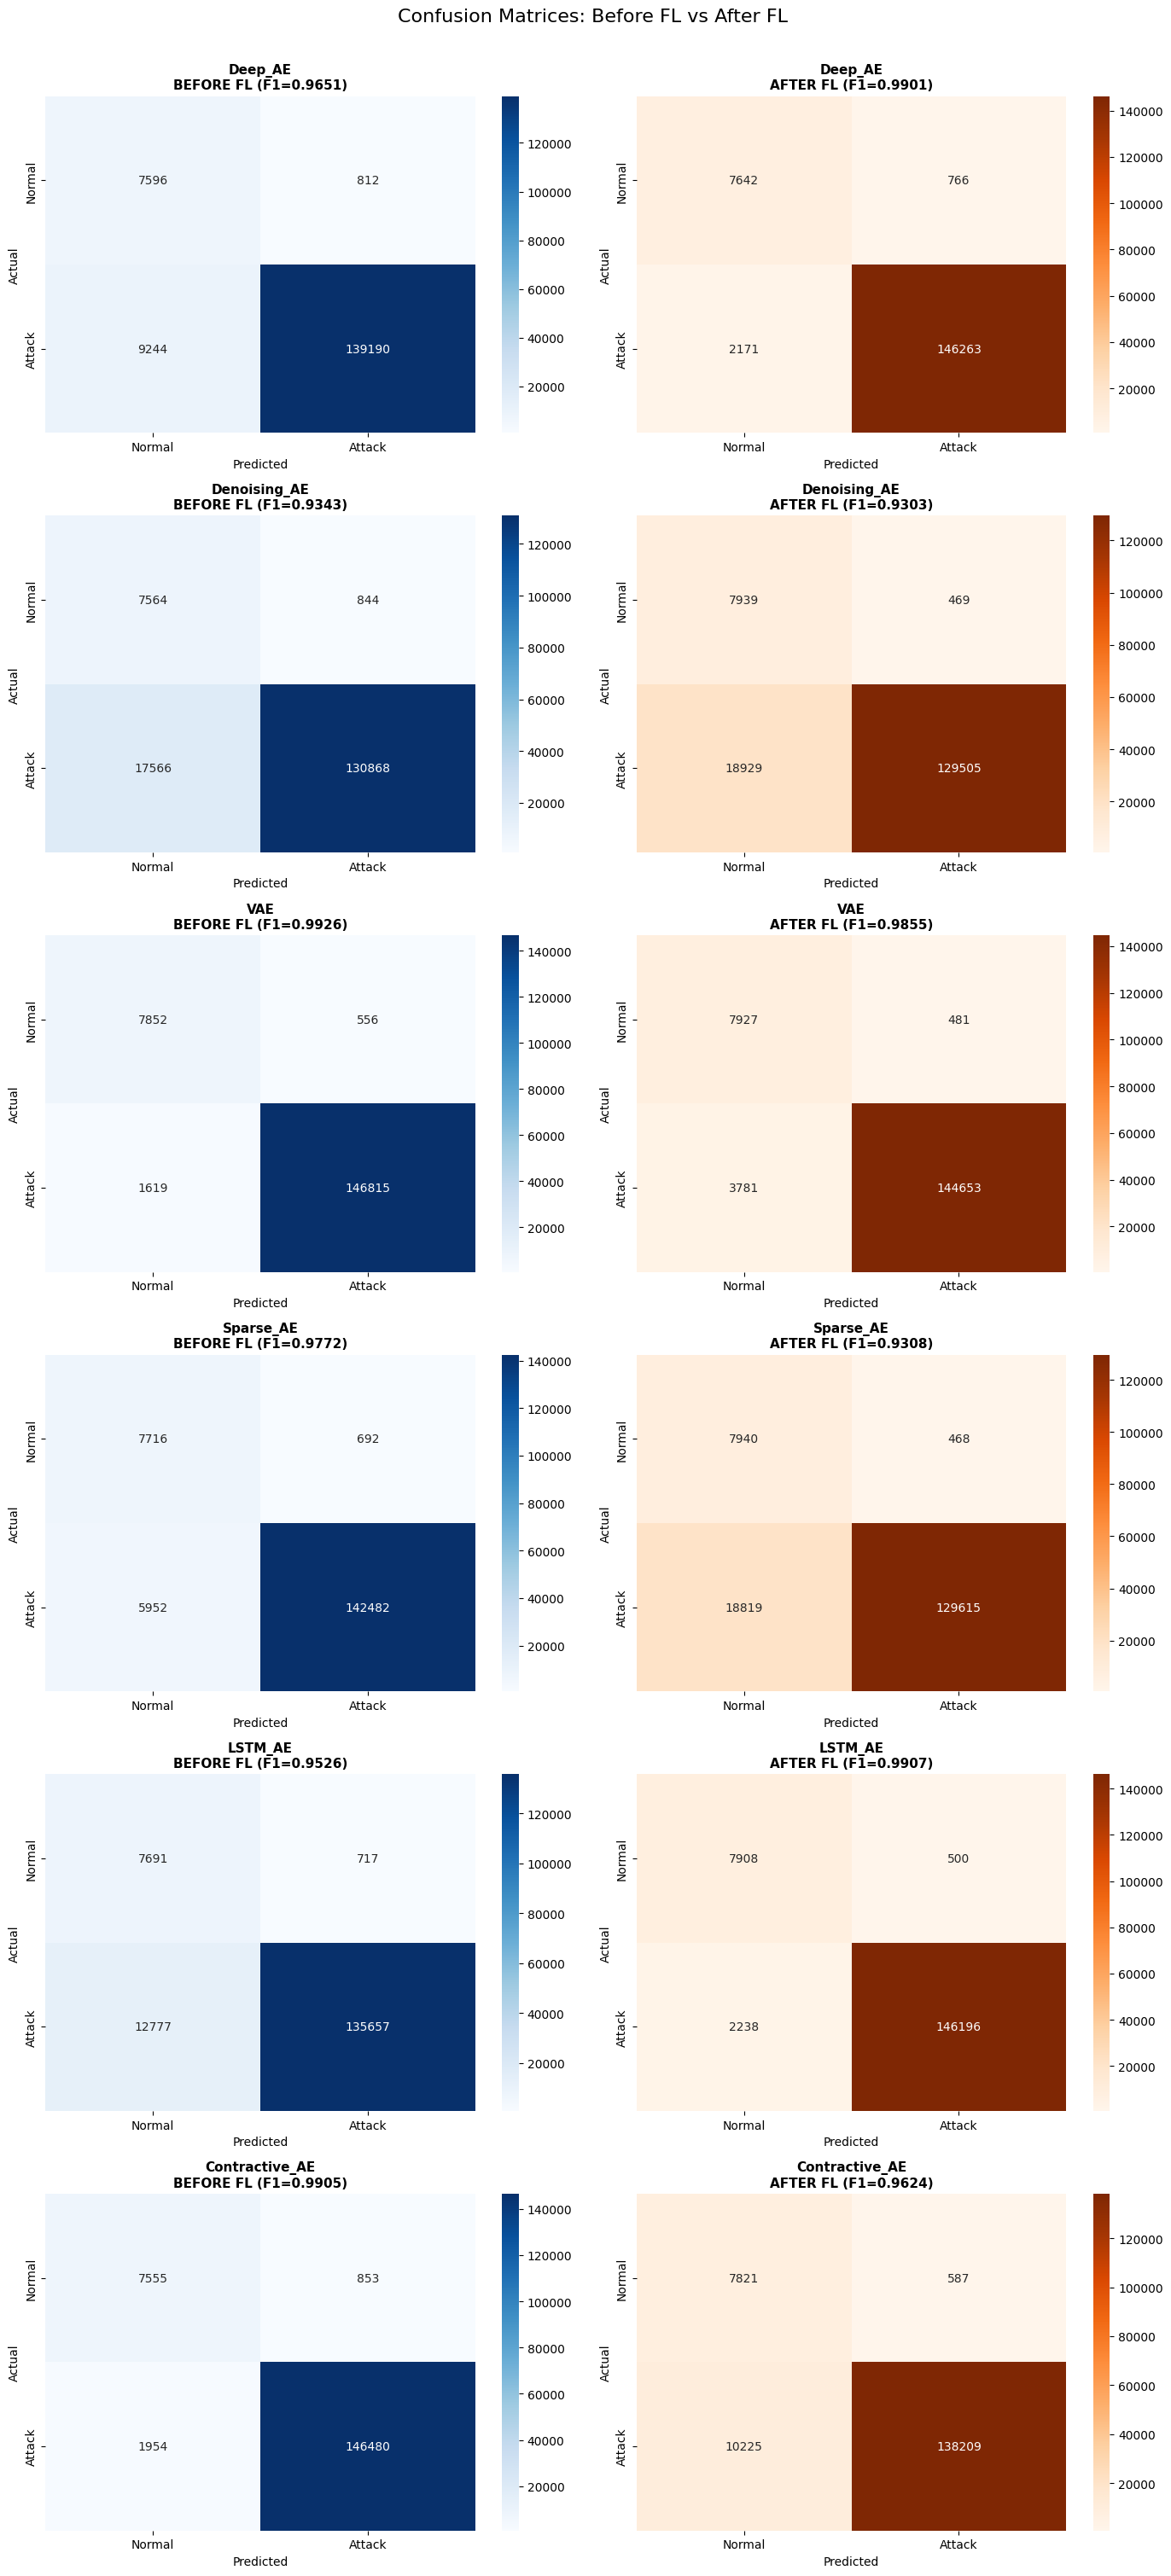

✅ Cell 26 Complete


In [ ]:
# ============================================================
#  CELL 26: Confusion Matrices — Before FL vs After FL
# ============================================================
num_models = len(BUILDERS)
fig, axes = plt.subplots(num_models, 2, figsize=(14, 5 * num_models))

if num_models == 1:
    axes = axes.reshape(1, 2)

for idx, name in enumerate(BUILDERS.keys()):
    c_errs, c_th = all_errors[name]
    c_pred = (c_errs > c_th).astype(int)
    c_cm = confusion_matrix(y_test, c_pred)
    c_f1 = f1_score(y_test, c_pred, zero_division=0)

    sns.heatmap(c_cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Normal', 'Attack'],
                yticklabels=['Normal', 'Attack'],
                ax=axes[idx, 0])
    axes[idx, 0].set_title(f'{name}\nBEFORE FL (F1={c_f1:.4f})',
                           fontsize=11, fontweight='bold')
    axes[idx, 0].set_xlabel('Predicted')
    axes[idx, 0].set_ylabel('Actual')

    f_errs, f_th = fl_all_errors[name]
    f_pred = (f_errs > f_th).astype(int)
    f_cm = confusion_matrix(y_test, f_pred)
    f_f1 = f1_score(y_test, f_pred, zero_division=0)

    sns.heatmap(f_cm, annot=True, fmt='d', cmap='Oranges',
                xticklabels=['Normal', 'Attack'],
                yticklabels=['Normal', 'Attack'],
                ax=axes[idx, 1])
    axes[idx, 1].set_title(f'{name}\nAFTER FL (F1={f_f1:.4f})',
                           fontsize=11, fontweight='bold')
    axes[idx, 1].set_xlabel('Predicted')
    axes[idx, 1].set_ylabel('Actual')

plt.suptitle('Confusion Matrices: Before FL vs After FL',
             fontsize=16, y=1.005)
plt.tight_layout()
plt.show()
print("✅ Cell 26 Complete")

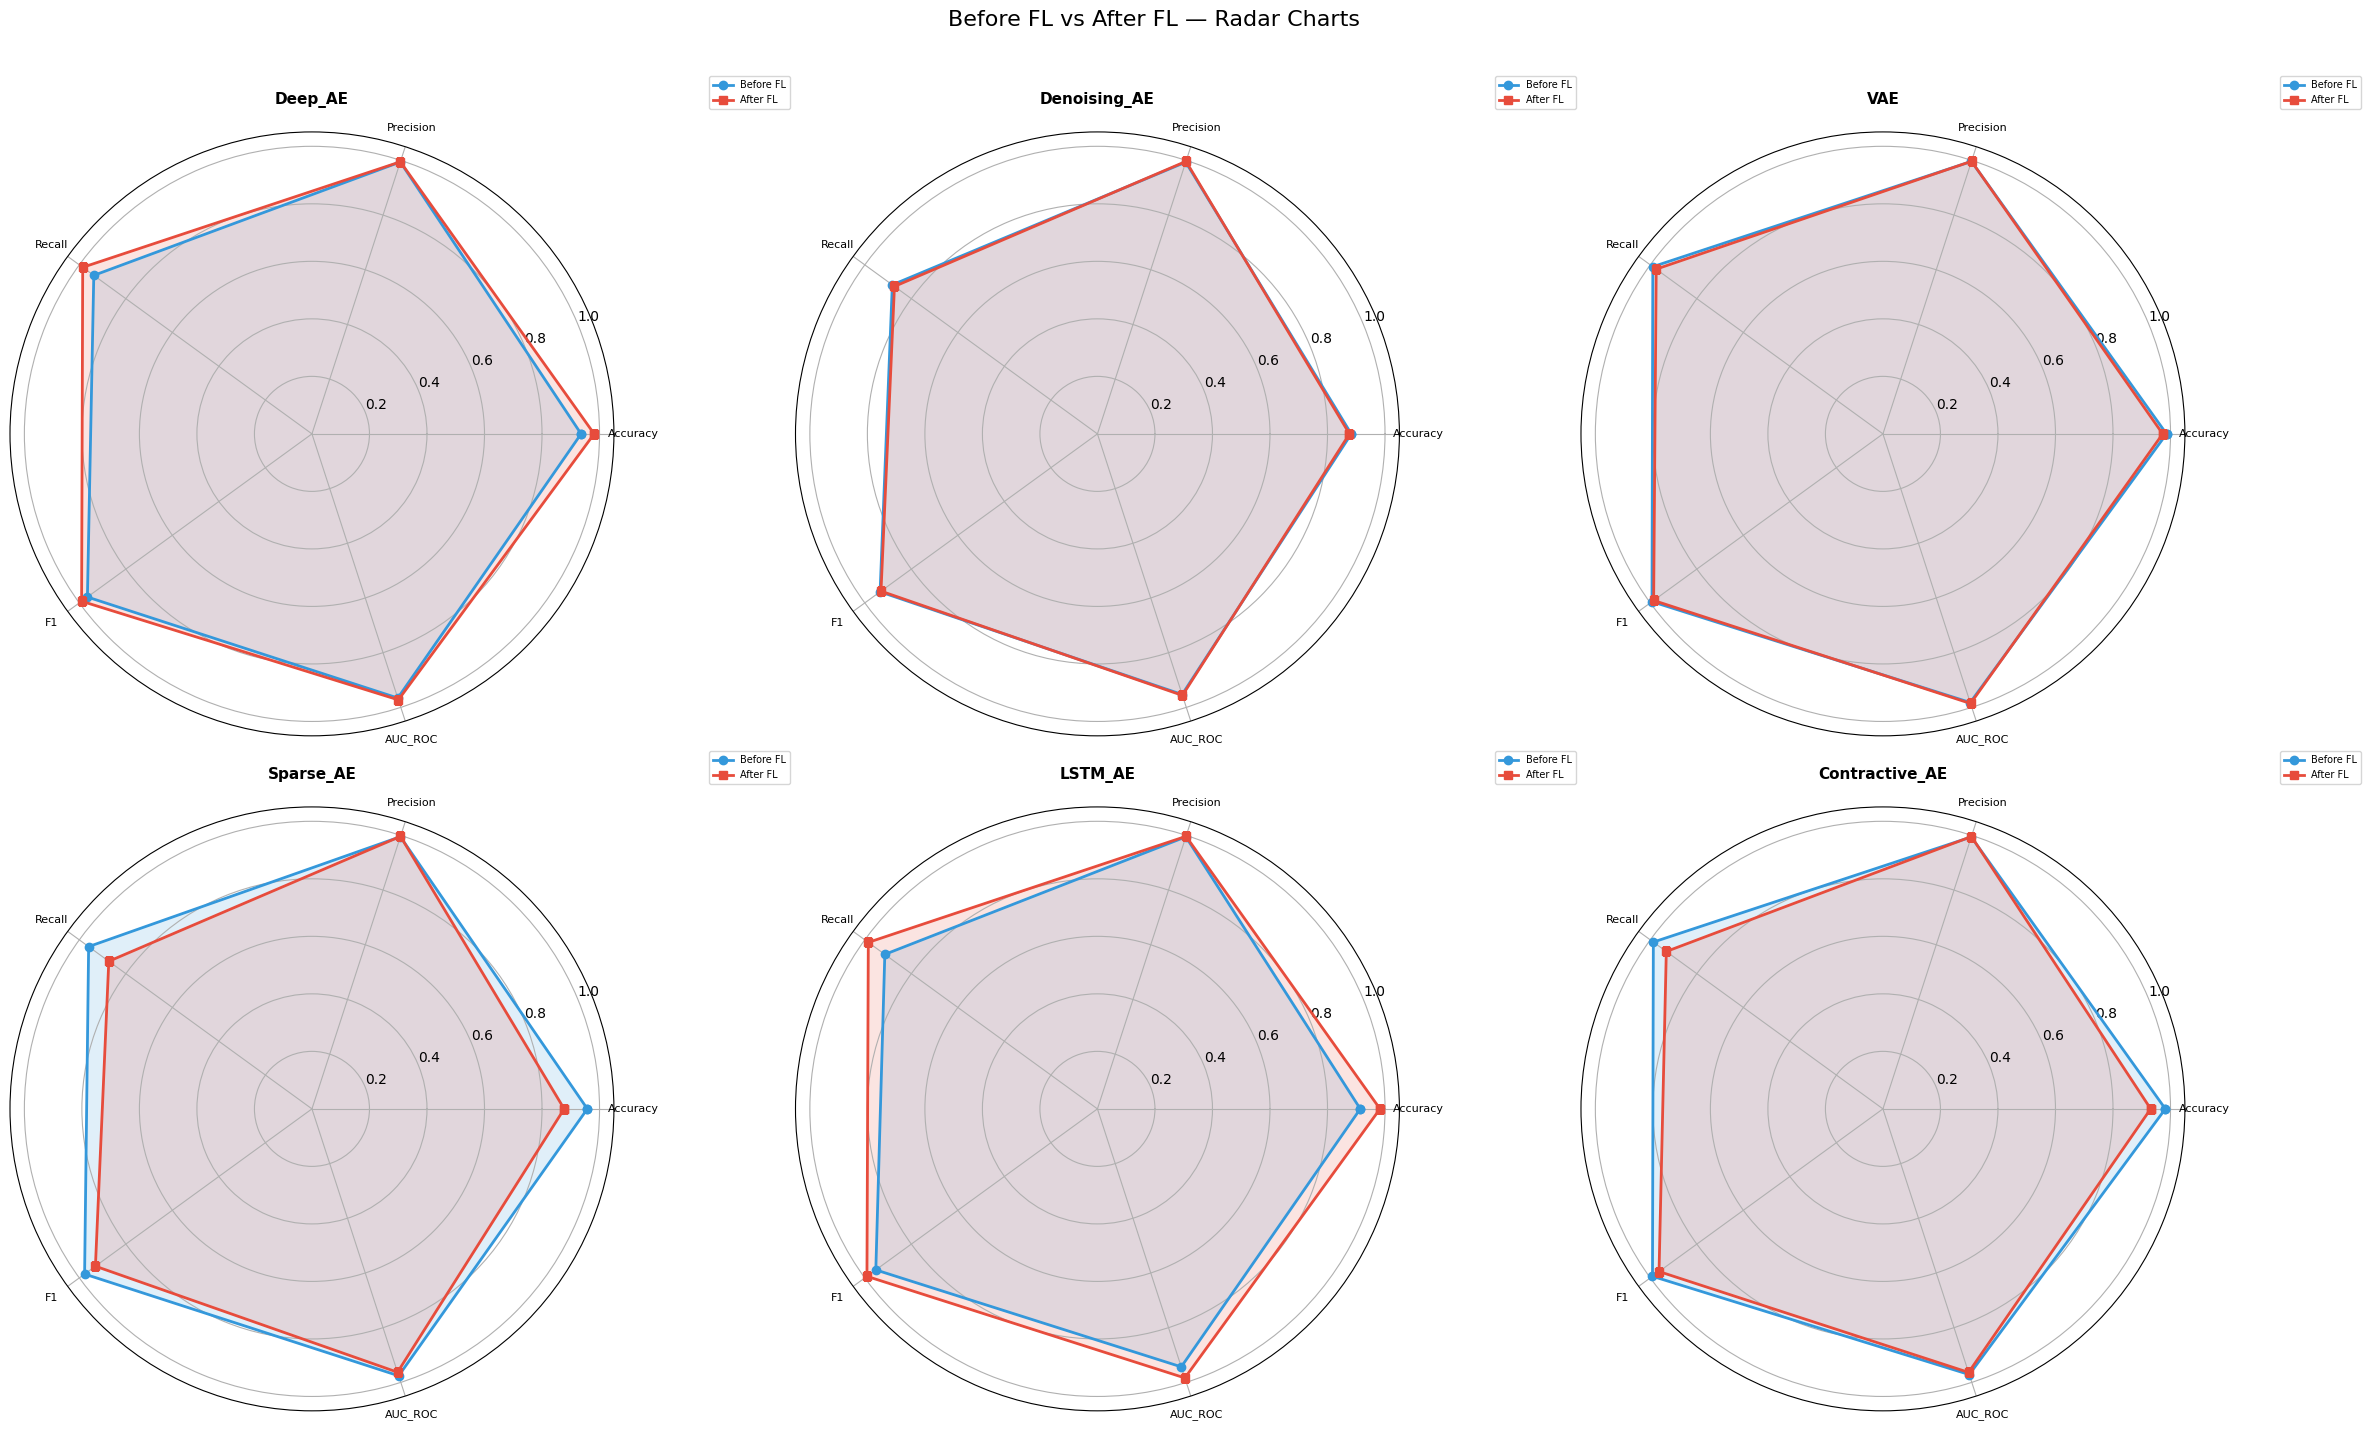

✅ Cell 27 Complete


In [ ]:
# ============================================================
#  CELL 27: Radar Charts — Before vs After FL
# ============================================================
metrics_radar = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC_ROC']
N = len(metrics_radar)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

NUM_MODELS = len(BUILDERS)
ncols = 3
nrows = (NUM_MODELS + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(24, 7 * nrows),
                         subplot_kw=dict(polar=True))
axes = axes.ravel()

for idx, name in enumerate(BUILDERS.keys()):
    ax = axes[idx]

    c_vals = [df_results.loc[df_results['Model'] == name, m].values[0]
              for m in metrics_radar]
    c_vals += c_vals[:1]

    f_vals = [df_fl.loc[df_fl['Model'] == f'FL_{name}', m].values[0]
              for m in metrics_radar]
    f_vals += f_vals[:1]

    ax.plot(angles, c_vals, 'o-', lw=2, color='#3498db', label='Before FL')
    ax.fill(angles, c_vals, alpha=0.15, color='#3498db')

    ax.plot(angles, f_vals, 's-', lw=2, color='#e74c3c', label='After FL')
    ax.fill(angles, f_vals, alpha=0.15, color='#e74c3c')

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metrics_radar, fontsize=8)
    ax.set_ylim(0, 1.05)
    ax.set_title(name, fontsize=11, fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=7)

for j in range(idx + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Before FL vs After FL — Radar Charts',
             fontsize=16, y=1.02)
plt.tight_layout()
plt.show()
print("✅ Cell 27 Complete")

In [ ]:
# ============================================================
#  CELL 28: FINAL SUMMARY — Winners + Classification Report
# ============================================================

print("\n" + "=" * 85)
print("  📊  FINAL SUMMARY TABLE")
print("=" * 85)

summary_data = []
for name in BUILDERS.keys():
    c_f1 = df_results.loc[df_results['Model'] == name, 'F1'].values[0]
    f_f1 = df_fl.loc[df_fl['Model'] == f'FL_{name}', 'F1'].values[0]

    c_auc = df_results.loc[df_results['Model'] == name, 'AUC_ROC'].values[0]
    f_auc = df_fl.loc[df_fl['Model'] == f'FL_{name}', 'AUC_ROC'].values[0]

    c_rec = df_results.loc[df_results['Model'] == name, 'Recall'].values[0]
    f_rec = df_fl.loc[df_fl['Model'] == f'FL_{name}', 'Recall'].values[0]

    c_prec = df_results.loc[df_results['Model'] == name, 'Precision'].values[0]
    f_prec = df_fl.loc[df_fl['Model'] == f'FL_{name}', 'Precision'].values[0]

    c_acc = df_results.loc[df_results['Model'] == name, 'Accuracy'].values[0]
    f_acc = df_fl.loc[df_fl['Model'] == f'FL_{name}', 'Accuracy'].values[0]

    summary_data.append({
        'Model': name,
        'Before_F1': c_f1, 'After_F1': f_f1, 'F1_Change': f_f1 - c_f1,
        'Before_AUC': c_auc, 'After_AUC': f_auc, 'AUC_Change': f_auc - c_auc,
        'Before_Recall': c_rec, 'After_Recall': f_rec, 'Recall_Change': f_rec - c_rec,
        'Before_Precision': c_prec, 'After_Precision': f_prec,
        'Before_Accuracy': c_acc, 'After_Accuracy': f_acc,
    })

df_summary = pd.DataFrame(summary_data)

print(f"\n  {'Model':<18} │ {'Before F1':>10} │ {'After F1':>10} │ {'F1 Δ':>8} │ "
      f"{'Before AUC':>11} │ {'After AUC':>10} │ {'AUC Δ':>8}")
print(f"  {'─' * 18}─┼─{'─' * 10}─┼─{'─' * 10}─┼─{'─' * 8}─┼─"
      f"{'─' * 11}─┼─{'─' * 10}─┼─{'─' * 8}")

for _, row in df_summary.iterrows():
    f1_a = "⬆️" if row['F1_Change'] > 0.001 else ("⬇️" if row['F1_Change'] < -0.001 else "➡️")
    auc_a = "⬆️" if row['AUC_Change'] > 0.001 else ("⬇️" if row['AUC_Change'] < -0.001 else "➡️")

    print(f"  {row['Model']:<18} │ {row['Before_F1']:>10.4f} │ {row['After_F1']:>10.4f} │ "
          f"{row['F1_Change']:>+7.4f}{f1_a} │ {row['Before_AUC']:>11.4f} │ "
          f"{row['After_AUC']:>10.4f} │ {row['AUC_Change']:>+7.4f}{auc_a}")

# Winners
best_before = df_results.sort_values('F1', ascending=False).iloc[0]
best_after = df_fl.sort_values('F1', ascending=False).iloc[0]
most_improved = df_summary.sort_values('F1_Change', ascending=False).iloc[0]

print(f"\n  {'=' * 80}")
print(f"  🏆 BEST BEFORE FL   : {best_before['Model']:<15} "
      f"(F1={best_before['F1']:.4f}, AUC={best_before['AUC_ROC']:.4f})")
print(f"  🏆 BEST AFTER FL    : {best_after['Model'].replace('FL_', ''):<15} "
      f"(F1={best_after['F1']:.4f}, AUC={best_after['AUC_ROC']:.4f})")
print(f"  📈 MOST IMPROVED    : {most_improved['Model']:<15} "
      f"(F1 Δ = {most_improved['F1_Change']:+.4f})")
print(f"  {'=' * 80}")

# Classification report for the absolute best
if best_after['F1'] >= best_before['F1']:
    best_name = best_after['Model'].replace('FL_', '')
    best_model = fl_models[best_name]
    errs, th = fl_all_errors[best_name]
    source = "After FL"
else:
    best_name = best_before['Model']
    best_model = trained_models[best_name]
    errs, th = all_errors[best_name]
    source = "Before FL"

y_pred_best = (errs > th).astype(int)
print(f"\n  📋 Classification Report — OVERALL BEST: {best_name} ({source})")
print(f"  {'─' * 60}")
print(classification_report(y_test, y_pred_best,
                            target_names=['Normal', 'Attack'], digits=4))

print("✅ Cell 28 Complete")


  📊  FINAL SUMMARY TABLE

  Model              │  Before F1 │   After F1 │     F1 Δ │  Before AUC │  After AUC │    AUC Δ
  ───────────────────┼────────────┼────────────┼──────────┼─────────────┼────────────┼─────────
  Deep_AE            │     0.9651 │     0.9901 │ +0.0249⬆️ │      0.9659 │     0.9725 │ +0.0067⬆️
  Denoising_AE       │     0.9343 │     0.9303 │ -0.0040⬇️ │      0.9529 │     0.9562 │ +0.0033⬆️
  VAE                │     0.9926 │     0.9855 │ -0.0072⬇️ │      0.9822 │     0.9858 │ +0.0036⬆️
  Sparse_AE          │     0.9772 │     0.9308 │ -0.0465⬇️ │      0.9759 │     0.9629 │ -0.0130⬇️
  LSTM_AE            │     0.9526 │     0.9907 │ +0.0381⬆️ │      0.9433 │     0.9838 │ +0.0406⬆️
  Contractive_AE     │     0.9905 │     0.9624 │ -0.0282⬇️ │      0.9714 │     0.9635 │ -0.0079⬇️

  🏆 BEST BEFORE FL   : VAE             (F1=0.9926, AUC=0.9822)
  🏆 BEST AFTER FL    : LSTM_AE         (F1=0.9907, AUC=0.9838)
  📈 MOST IMPROVED    : LSTM_AE         (F1 Δ = +0.0381)

  📋 Class